# Predicción de quiebra empresarial

**Trabajo Fin de Máster**

Ana Rodríguez Rivas

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,fbeta_score,roc_auc_score,average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, silhouette_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

C:\Users\anaro\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y diagnóstico inicial del dataset

In [2]:
df = pd.read_csv("data.csv")

df.columns = df.columns.str.strip()

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras columnas:")
print(df.columns.tolist()[:20])

print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nValores nulos totales:")
print(df.isnull().sum().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

Dimensiones del dataset:
(6819, 96)

Primeras columnas:
['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue', 'Continuous interest rate (after tax)', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons']

Tipos de datos:
float64    93
int64       3
Name: count, dtype: int64

Valores nulos totales:
0

Filas duplicadas:
0


**Variable Objetivo**

In [4]:
target = "Bankrupt?"

print("Distribución absoluta de la variable objetivo:")
print(df[target].value_counts().sort_index())

print("\nDistribución porcentual de la variable objetivo:")
print((df[target].value_counts(normalize=True).sort_index() * 100).round(2))
y = df[target]

Distribución absoluta de la variable objetivo:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Distribución porcentual de la variable objetivo:
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


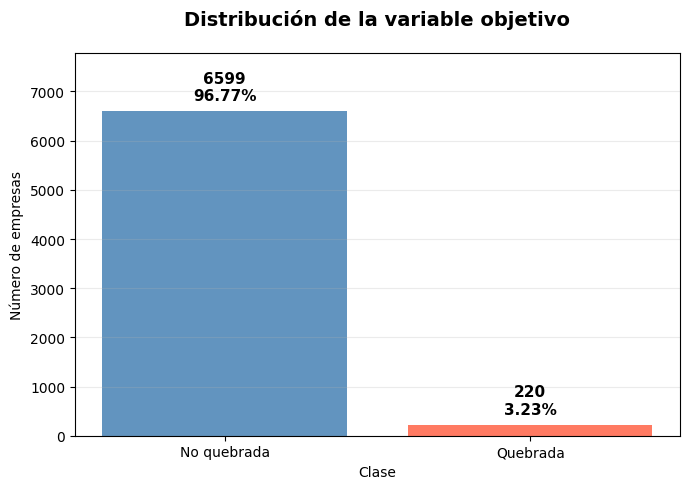

In [5]:
target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

labels = ["No quebrada", "Quebrada"]
colors = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, target_counts, color=colors, alpha=0.85)

ax.set_title("Distribución de la variable objetivo", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de empresas")
ax.grid(axis="y", alpha=0.25)

ax.set_ylim(0, target_counts.max() * 1.18)

for i, bar in enumerate(bars):
    value = target_counts.iloc[i]
    percentage = target_percentages.iloc[i]

    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + target_counts.max() * 0.025,f"{value}\n{percentage:.2f}%",ha="center",va="bottom",fontsize=11,fontweight="bold")

plt.tight_layout()
plt.show()


La distribución de la variable objetivo confirma un problema de clasificación desbalanceada, un modelo puede alcanzar una accuracy elevada simplemente clasificando casi todas las empresas como no quebradas. Por este motivo, el análisis no debe centrarse únicamente en la accuracy. Desde una perspectiva de riesgo financiero, la sensibilidad o recall de la clase quebrada, el F2-score y el PR-AUC son especialmente relevantes, ya que el coste de clasificar como sana a una empresa que realmente quiebra puede ser superior al coste de generar una falsa alarma.

In [6]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes:")
print(constant_cols)

Columnas constantes:
['Net Income Flag']


In [7]:
print("Net Income Flag" in df.columns)

True


In [8]:
df = df.drop(columns=["Net Income Flag"])

## 2b. Variables categóricas

`Bankrupt?` y `Liability-Assets Flag` se convierten a tipo categórico (factor).
Así el EDA las muestra con etiquetas legibles ("No" / "Sí") y quedan como factor para el análisis.

Al preparar X e y para los modelos, `y` se extrae como 0/1 con `.cat.codes`.

In [9]:
for col in ["Bankrupt?", "Liability-Assets Flag"]:
    df[col] = pd.Categorical(df[col].map({0: "No", 1: "Sí"}), categories=["No", "Sí"])

df[["Bankrupt?", "Liability-Assets Flag"]].head()

,Bankrupt?,Liability-Assets Flag
0,Sí,No
1,Sí,No
2,Sí,No
3,Sí,No
4,Sí,No


## 2c. Transformación logarítmica

Se aplica `log1p(x)` a variables de rotación, tasas de crecimiento y ratios con colas largas. `log1p` maneja correctamente los valores iguales a cero.

Beneficia principalmente a la regresión logística (sensible a la escala).
Random Forest y XGBoost son invariantes a transformaciones monótonas, así que no les afecta.

In [10]:
target = "Bankrupt?"

# X: solo variables numéricas (excluye Bankrupt? y Liability-Assets Flag categóricos)
X = df.drop(columns=[target]).select_dtypes(include=["number"])

# y: 0 = No quebrada, 1 = Quebrada
# cat.codes asigna códigos según el orden de categories=["No","Sí"]: No→0, Sí→1
y = df[target].cat.codes.astype(int)

print("Dimensiones de X:", X.shape)
print("\nDistribución de y (0=No quebrada, 1=Quebrada):")
print(y.value_counts().sort_index())

Dimensiones de X: (6819, 93)

Distribución de y (0=No quebrada, 1=Quebrada):
0    6599
1     220
Name: count, dtype: int64


In [11]:
variables_log = ["Current Asset Turnover Rate", "Cash Turnover Rate","Quick Asset Turnover Rate","Inventory Turnover Rate (times)","Total Asset Growth Rate","Fixed Assets Turnover Frequency","Operating Expense Rate","Research and development expense rate","Total debt/Total net worth","Inventory/Current Liability","Total assets to GNP price","Accounts Receivable Turnover","Average Collection Days","Cash/Current Liability","Allocation rate per person","Long-term Liability to Current Assets","Net Value Growth Rate","Quick Ratio","Quick Assets/Current Liability","Revenue per person","Fixed Assets to Assets","Revenue Per Share (Yuan ¥)","Current Ratio","Interest-bearing debt interest rate","Total income/Total expense","Contingent liabilities/Net worth","Realized Sales Gross Profit Growth Rate","Continuous Net Profit Growth Rate","Total Asset Return Growth Rate Ratio","Degree of Financial Leverage (DFL)","Inventory/Working Capital","Non-industry income and expenditure/revenue","Equity to Long-term Liability","Liability to Equity","Long-term fund suitability ratio (A)","Current Liabilities/Equity","Current Liability to Equity","Borrowing dependency","Cash Flow to Equity","Current Liability to Current Assets","Inventory and accounts receivable/Net value",]

variables_log_ok = [c for c in variables_log if c in X.columns]
variables_log_missing = [c for c in variables_log if c not in X.columns]

for col in variables_log_ok:
    X[col] = np.log1p(X[col])

print(f"Variables transformadas con log1p: {len(variables_log_ok)}")
print(f"Variables sin transformar: {X.shape[1] - len(variables_log_ok)}")
print(f"Total variables en X: {X.shape[1]}")
if variables_log_missing:
    print(f"No encontradas: {variables_log_missing}")

Variables transformadas con log1p: 41
Variables sin transformar: 52
Total variables en X: 93


In [12]:
skewness = X.skew().sort_values(ascending=False)

resumen_skew = pd.DataFrame({"skewness": skewness,"skewness_abs": skewness.abs(),"transformada": skewness.index.isin(variables_log_ok)})

print("Variables con mayor asimetría:")
print(resumen_skew.head(30).round(2))

Variables con mayor asimetría:
                                             skewness  skewness_abs  \
Total income/Total expense                      82.08         82.08   
Current Ratio                                   81.91         81.91   
Contingent liabilities/Net worth                77.04         77.04   
Realized Sales Gross Profit Growth Rate         74.05         74.05   
Net Value Growth Rate                           58.50         58.50   
Revenue per person                              57.10         57.10   
Fixed Assets to Assets                          55.14         55.14   
Continuous Net Profit Growth Rate               54.74         54.74   
Quick Assets/Current Liability                  47.58         47.58   
Total Asset Return Growth Rate Ratio            47.30         47.30   
Degree of Financial Leverage (DFL)              39.84         39.84   
Revenue Per Share (Yuan ¥)                      36.65         36.65   
Total debt/Total net worth                    

In [13]:
no_transformadas = [c for c in X.columns if c not in variables_log_ok]

resumen_no_transformadas = pd.DataFrame({"skewness": X.skew()[no_transformadas]}).sort_values("skewness", ascending=False)

print(f"Variables no transformadas: {len(no_transformadas)}")
print(resumen_no_transformadas.round(2))

Variables no transformadas: 52
                                                    skewness
Total expense/Assets                                    9.48
Net Worth Turnover Rate (times)                         8.96
Operating profit/Paid-in capital                        8.95
Operating Profit Per Share (Yuan ¥)                     8.81
Cash Flow Per Share                                     8.02
Operating profit per person                             7.79
Equity to Liability                                     7.40
Net profit before tax/Paid-in capital                   6.38
Per Share Net profit before tax (Yuan ¥)                6.00
Persistent EPS in the Last Four Seasons                 5.14
Net Value Per Share (B)                                 4.56
Net Value Per Share (A)                                 4.52
Net Value Per Share (C)                                 4.51
Cash flow rate                                          3.99
Operating Funds to Liability                          

In [14]:
negativos = pd.DataFrame({"skewness": X.skew(),"min": X.min(),"n_negativos": (X < 0).sum(),"pct_negativos": ((X < 0).mean() * 100).round(2)}).sort_values("skewness", ascending=False)

print(negativos.head(35))

                                              skewness  min  n_negativos  \
Total income/Total expense                   82.076512  0.0            0   
Current Ratio                                81.908514  0.0            0   
Contingent liabilities/Net worth             77.039435  0.0            0   
Realized Sales Gross Profit Growth Rate      74.048079  0.0            0   
Net Value Growth Rate                        58.502201  0.0            0   
Revenue per person                           57.096289  0.0            0   
Fixed Assets to Assets                       55.138570  0.0            0   
Continuous Net Profit Growth Rate            54.740412  0.0            0   
Quick Assets/Current Liability               47.577819  0.0            0   
Total Asset Return Growth Rate Ratio         47.298766  0.0            0   
Degree of Financial Leverage (DFL)           39.844278  0.0            0   
Revenue Per Share (Yuan ¥)                   36.650661  0.0            0   
Total debt/T

In [15]:
print("Net Income Flag" in df.columns)

False


## 3. Análisis exploratorio de datos (EDA)

El EDA se orienta a comprender la estructura de los ratios financieros, detectar variables con muchos ceros, observar correlaciones con la quiebra y analizar valores extremos. No se realiza una limpieza agresiva de outliers porque, en ratios financieros, los valores extremos pueden contener información relevante sobre deterioro económico, tensión de liquidez o riesgo de insolvencia.

In [16]:
summary = df.describe().T
summary.head(20)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,5.051796e-01,6.068564e-02,0.0,0.476527,5.027056e-01,5.355628e-01,1.000000e+00
ROA(A) before interest and % after tax,6819.0,5.586249e-01,6.562003e-02,0.0,0.535543,5.598016e-01,5.891572e-01,1.000000e+00
ROA(B) before interest and depreciation after tax,6819.0,5.535887e-01,6.159481e-02,0.0,0.527277,5.522780e-01,5.841051e-01,1.000000e+00
Operating Gross Margin,6819.0,6.079480e-01,1.693381e-02,0.0,0.600445,6.059975e-01,6.139142e-01,1.000000e+00
Realized Sales Gross Margin,6819.0,6.079295e-01,1.691607e-02,0.0,0.600434,6.059759e-01,6.138421e-01,1.000000e+00
Operating Profit Rate,6819.0,9.987551e-01,1.301003e-02,0.0,0.998969,9.990222e-01,9.990945e-01,1.000000e+00
Pre-tax net Interest Rate,6819.0,7.971898e-01,1.286899e-02,0.0,0.797386,7.974636e-01,7.975788e-01,1.000000e+00
After-tax net Interest Rate,6819.0,8.090836e-01,1.360065e-02,0.0,0.809312,8.093752e-01,8.094693e-01,1.000000e+00
Non-industry income and expenditure/revenue,6819.0,3.036229e-01,1.116344e-02,0.0,0.303466,3.035255e-01,3.035852e-01,1.000000e+00
Continuous interest rate (after tax),6819.0,7.813814e-01,1.267900e-02,0.0,0.781567,7.816350e-01,7.817354e-01,1.000000e+00


**Porcentaje de ceros por variable**

In [17]:
zero_percentages = (X == 0).mean().sort_values(ascending=False) * 100
display(zero_percentages.head(20).round(2).to_frame("% ceros"))

,% ceros
Long-term Liability to Current Assets,37.67
Tax rate (A),37.66
Research and development expense rate,20.88
Interest-bearing debt interest rate,13.07
Inventory/Current Liability,3.33
Fixed Assets Turnover Frequency,0.12
Total Asset Turnover,0.12
Average Collection Days,0.10
Accounts Receivable Turnover,0.10
Fixed Assets to Assets,0.09


**Análisis Liability-Assets Flag**

In [18]:
tabla_flag = pd.crosstab(df["Liability-Assets Flag"], df["Bankrupt?"])
tabla_flag["Total"] = tabla_flag.sum(axis=1)
tabla_flag["Tasa de quiebra (%)"] = (tabla_flag["Sí"] / tabla_flag["Total"] * 100).round(2)

display(tabla_flag)

Bankrupt?,No,Sí,Total,Tasa de quiebra (%)
Liability-Assets Flag,,,,
No,6597,214,6811,3.14
Sí,2,6,8,75.00


Aunque Liability-Assets Flag presenta un 99.88% de ceros, no se trata de una variable sin información: las 8 observaciones con valor 1 presentan una tasa de quiebra del 75%, frente al 3.14% del resto. Su poder discriminante en esos casos extremos es muy elevado. En modelos de árboles como Random Forest y XGBoost, este tipo de variable indicadora de situación límite puede capturarse eficazmente sin desestabilizar el modelo.

**Número de valores únicos por variable**

In [19]:
unique_values = X.nunique().sort_values()

print("Variables con menos valores únicos:")
display(unique_values.head(20).to_frame("n_valores_unicos"))

Variables con menos valores únicos:


,n_valores_unicos
Total Asset Turnover,381
Net Worth Turnover Rate (times),741
Interest-bearing debt interest rate,1080
Operating Profit Per Share (Yuan ¥),1236
Persistent EPS in the Last Four Seasons,1358
Per Share Net profit before tax (Yuan ¥),1522
Research and development expense rate,1536
Cash Flow Per Share,1545
Accounts Receivable Turnover,1593
Total Asset Growth Rate,1751


**Matriz de correlación**

In [20]:
df_corr = X.copy()
df_corr[target] = y

correlations_with_target = df_corr.corr()[target].drop(target)
correlations_sorted = correlations_with_target.abs().sort_values(ascending=False)

print("Variables más relacionadas linealmente con la quiebra:")
display(pd.DataFrame({"correlacion": correlations_with_target.loc[correlations_sorted.index],"correlacion_abs": correlations_sorted}).head(20).round(4))

Variables más relacionadas linealmente con la quiebra:


,correlacion,correlacion_abs
Net Income to Total Assets,-0.3155,0.3155
ROA(A) before interest and % after tax,-0.2829,0.2829
ROA(B) before interest and depreciation after tax,-0.2731,0.2731
ROA(C) before interest and depreciation before interest,-0.2608,0.2608
Net worth/Assets,-0.2502,0.2502
Debt ratio %,0.2502,0.2502
Persistent EPS in the Last Four Seasons,-0.2196,0.2196
Retained Earnings to Total Assets,-0.2178,0.2178
Net profit before tax/Paid-in capital,-0.2079,0.2079
Per Share Net profit before tax (Yuan ¥),-0.2014,0.2014


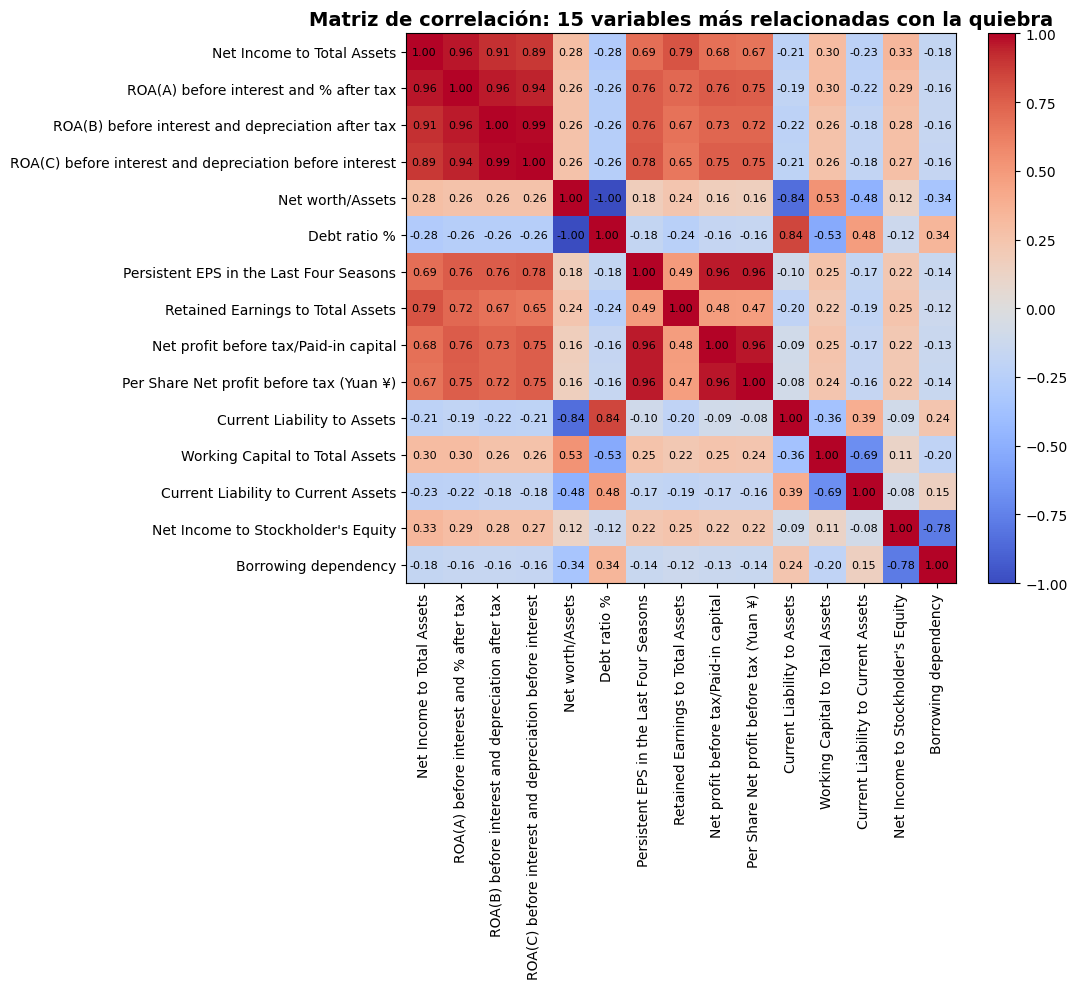

In [21]:
top_15_vars = correlations_sorted.head(15).index.tolist()

corr_subset = X[top_15_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_subset, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_title("Matriz de correlación: 15 variables más relacionadas con la quiebra",fontsize=14, fontweight="bold")
ax.set_xticks(np.arange(len(corr_subset.columns)))
ax.set_yticks(np.arange(len(corr_subset.index)))
ax.set_xticklabels(corr_subset.columns, rotation=90)
ax.set_yticklabels(corr_subset.index)

for i in range(len(corr_subset.index)):
    for j in range(len(corr_subset.columns)):
        ax.text(j, i, f"{corr_subset.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

La correlación permite identificar asociaciones lineales simples entre ratios financieros y quiebra, pero no debe interpretarse como prueba causal ni como criterio único de selección. La literatura justifica precisamente el uso de modelos de ensamble porque pueden captar relaciones no lineales e interacciones entre variables que una correlación bivariante no recoge.

In [22]:
X_numeric = X.select_dtypes(include=["number"])
Q1 = X_numeric.quantile(0.25)
Q3 = X_numeric.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (X_numeric < lower_bound) | (X_numeric > upper_bound)

outlier_summary = pd.DataFrame({"n_outliers": outlier_mask.sum(),"pct_outliers": outlier_mask.mean() * 100,"min": X_numeric.min(),"p01": X_numeric.quantile(0.01),"q1": X_numeric.quantile(0.25),"median": X_numeric.median(),"q3": X_numeric.quantile(0.75),"p99": X_numeric.quantile(0.99),"max": X_numeric.max(),"pct_zeros": (X_numeric == 0).mean() * 100,"unique_values": X_numeric.nunique()}).sort_values("pct_outliers", ascending=False)

outlier_summary.head(20).round(4)

,n_outliers,pct_outliers,min,p01,q1,median,q3,p99,max,pct_zeros,unique_values
Degree of Financial Leverage (DFL),1503,22.0414,0.0,0.0250,0.0264,0.0265,0.0266,0.0359,0.6931,0.0147,6240
Interest Coverage Ratio (Interest expense to EBIT),1421,20.8388,0.0,0.5552,0.5652,0.5653,0.5657,0.5730,1.0000,0.0147,6240
Fixed Assets Turnover Frequency,1418,20.7948,0.0,0.0001,0.0002,0.0006,0.0036,22.9703,23.0249,0.1173,2451
Current Asset Turnover Rate,1399,20.5162,0.0,0.0001,0.0001,0.0002,0.0005,23.0044,23.0259,0.0147,6261
Total Asset Growth Rate,1395,20.4575,0.0,0.0001,22.3043,22.5796,22.7234,23.0014,23.0249,0.0147,1751
Interest Expense Ratio,1362,19.9736,0.0,0.6242,0.6306,0.6307,0.6311,0.6383,1.0000,0.0147,3794
Cash Flow to Liability,1212,17.7739,0.0,0.3940,0.4571,0.4598,0.4642,0.5522,1.0000,0.0147,6819
No-credit Interval,1139,16.7033,0.0,0.6154,0.6236,0.6239,0.6242,0.6334,1.0000,0.0147,6819
Non-industry income and expenditure/revenue,1095,16.0581,0.0,0.2641,0.2650,0.2651,0.2651,0.2661,0.6931,0.0147,2551
Cash Flow to Sales,1052,15.4275,0.0,0.6714,0.6716,0.6716,0.6716,0.6718,1.0000,0.0147,6819


**Variables con mayor porcentaje de outliers**

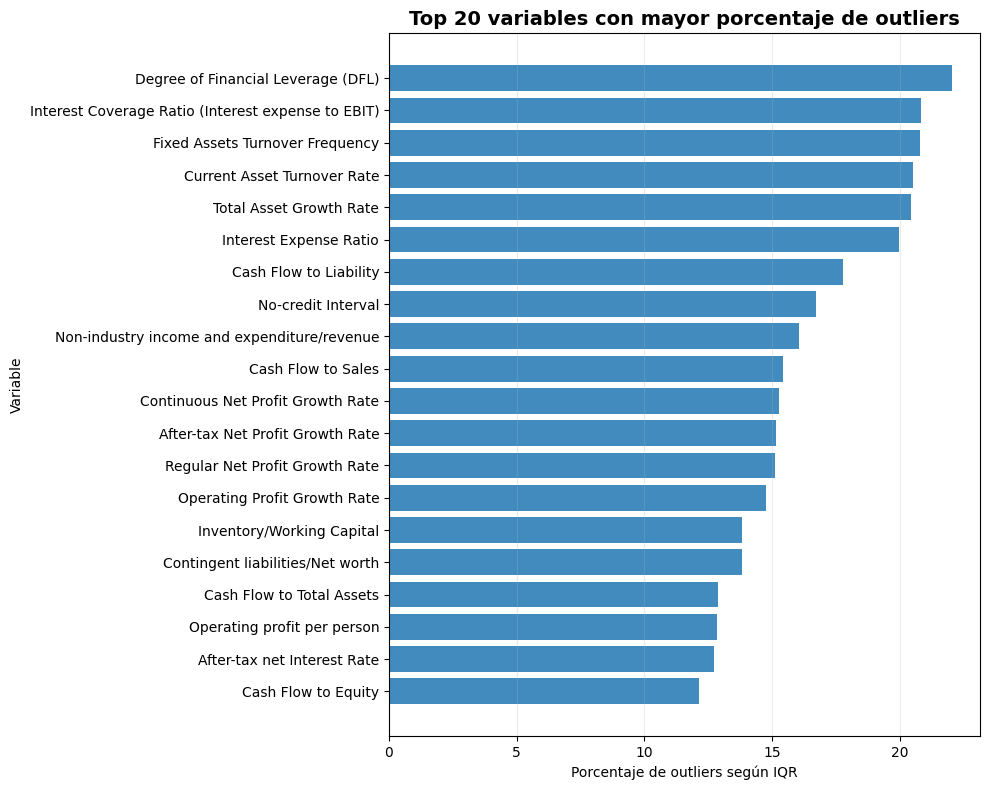

In [23]:
top_20_outliers = outlier_summary.head(20).sort_values("pct_outliers")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20_outliers.index, top_20_outliers["pct_outliers"], alpha=0.85)
ax.set_title("Top 20 variables con mayor porcentaje de outliers", fontsize=14, fontweight="bold")
ax.set_xlabel("Porcentaje de outliers según IQR")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

Los valores extremos no se eliminan. En el análisis de insolvencia, un ratio anormalmente elevado o reducido puede reflejar tensión financiera real. Por tanto, se documentan los outliers, pero se conservan para los modelos principales salvo que exista una justificación económica o contable clara para tratarlos.

## 5. PCA exploratorio

El Análisis de Componentes Principales se utiliza aquí como herramienta exploratoria para estudiar la dimensionalidad del dataset. No se usa como entrada principal de los modelos finales, ya que Random Forest y XGBoost pueden trabajar con las variables originales y capturar relaciones no lineales sin imponer una transformación lineal previa.

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled,columns=X.columns,index=X.index)

X_scaled_df.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Current Liability to Current Assets,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,-2.217909,-2.045798,-2.400361,-0.383334,-0.382638,0.016456,-0.023516,-0.020165,-0.094563,-0.031281,...,3.120376,-2.254317,-0.053359,-0.084274,-0.383465,-0.861611,0.768207,-0.070705,-0.098978,-0.622067
1,-0.673828,-0.311068,-0.598450,0.135068,0.136307,0.014671,0.014799,0.015966,-0.002635,0.009823,...,0.616170,-0.309033,-0.054092,-0.021388,0.135253,-0.029804,0.275995,17.612679,0.364559,-0.535573
2,-1.303672,-0.908420,-1.319910,-0.383759,-0.388177,0.007858,-0.061111,-0.051183,-0.156349,-0.086566,...,-0.216249,-0.820510,-0.028549,-0.005984,-0.383698,-0.249820,0.767175,-0.074498,-0.125015,-0.621960
3,-1.735886,-1.636209,-1.556340,-1.441418,-1.441832,-0.004257,-0.017313,-0.008676,-0.023530,-0.011077,...,1.324611,-1.691222,-0.058255,-0.080226,-1.441526,-0.392864,0.110905,-0.062773,-0.052562,-0.471826
4,-0.661778,-0.307745,-0.508050,-0.541238,-0.540708,0.016758,0.013703,0.016186,-0.010861,0.013300,...,0.614338,-0.316008,-0.057741,-0.032052,-0.541255,-0.029564,-0.138821,-0.223591,0.776395,-0.241715


In [25]:
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(X_scaled)
print(f"KMO global: {kmo_model:.4f}")

KMO global: 0.6963


C:\Users\anaro\PyCharmMiscProject\.venv\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [26]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
explained_var_cum = explained_var.cumsum()

explained_variance = pd.DataFrame({"Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],"Varianza explicada (%)": explained_var * 100,"Varianza acumulada (%)": explained_var_cum * 100})

explained_variance.round(2)

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,13.72,13.72
1,PC2,7.49,21.21
2,PC3,5.17,26.38
3,PC4,5.05,31.44
4,PC5,4.24,35.68
...,...,...,...
88,PC89,0.00,100.00
89,PC90,0.00,100.00
90,PC91,0.00,100.00
91,PC92,0.00,100.00


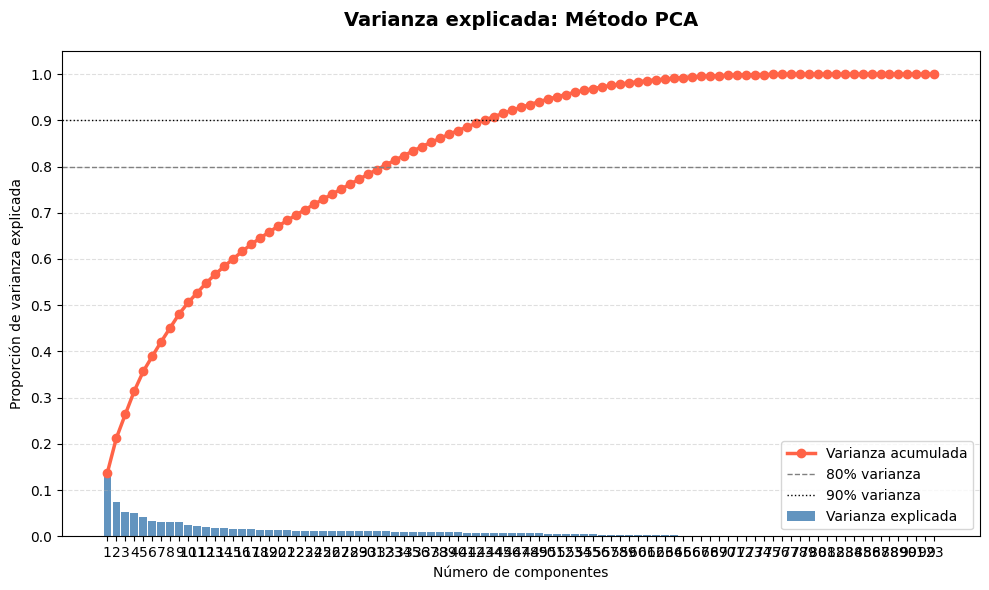

In [27]:
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(10, 6))
plt.bar(components,explained_var,width=0.85,color="steelblue",alpha=0.85,label="Varianza explicada")
plt.plot(components,explained_var_cum,marker="o",color="tomato",linewidth=2.5,label="Varianza acumulada")
plt.axhline(y=0.8,color="gray",linestyle="--",linewidth=1,label="80% varianza")
plt.axhline(y=0.9,color="black",linestyle=":",linewidth=1,label="90% varianza")

plt.xlabel("Número de componentes")
plt.ylabel("Proporción de varianza explicada")
plt.title("Varianza explicada: Método PCA", fontsize=14, fontweight="bold", pad=18)

plt.xticks(components)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.grid(True, which="both", axis="y", linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

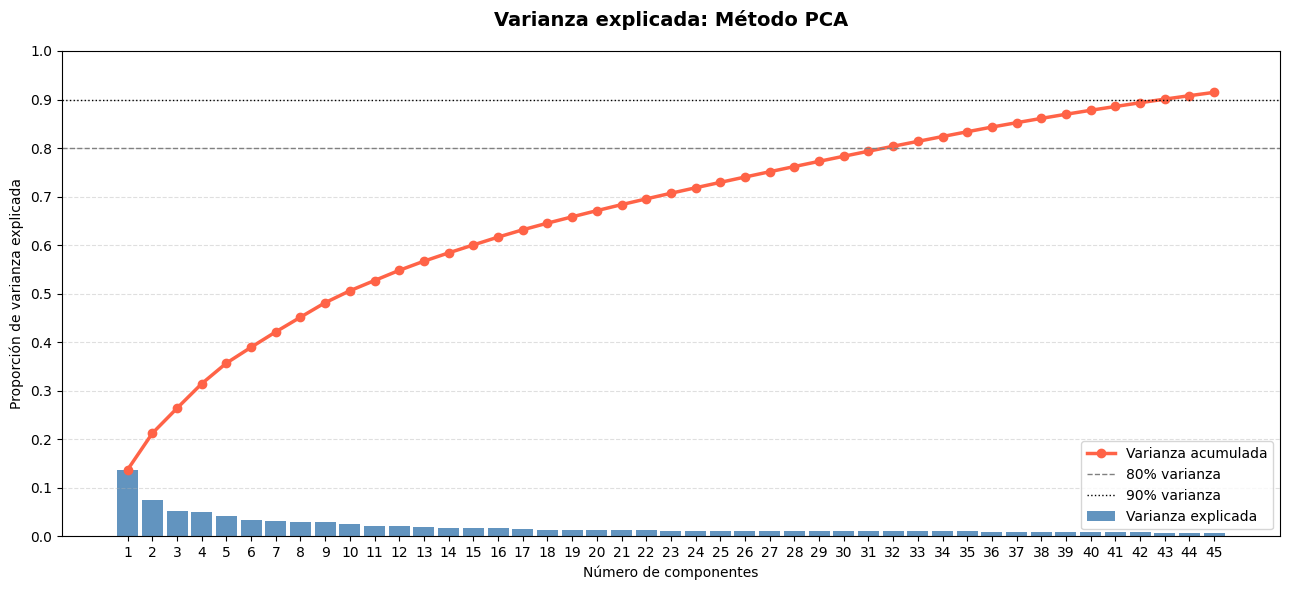

In [28]:
n_components_plot = 45

components = np.arange(1, n_components_plot + 1)

plt.figure(figsize=(13, 6))

plt.bar(components,explained_var[:n_components_plot],width=0.85,color="steelblue",alpha=0.85,label="Varianza explicada")
plt.plot(components,explained_var_cum[:n_components_plot],marker="o",color="tomato",linewidth=2.5,label="Varianza acumulada")

plt.axhline(y=0.8,color="gray",linestyle="--",linewidth=1,label="80% varianza")
plt.axhline(y=0.9,color="black",linestyle=":",linewidth=1,label="90% varianza")

plt.xlabel("Número de componentes")
plt.ylabel("Proporción de varianza explicada")
plt.title("Varianza explicada: Método PCA", fontsize=14, fontweight="bold", pad=18)

plt.xticks(components)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.grid(True, which="both", axis="y", linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()
plt.show()

**Matriz de loadings**

In [29]:
loadings = pd.DataFrame(pca.components_.T,index=X.columns,columns=[f"PC{i+1}" for i in range(pca.n_components_)])
loadings.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC84,PC85,PC86,PC87,PC88,PC89,PC90,PC91,PC92,PC93
ROA(C) before interest and depreciation before interest,0.2350,0.0800,-0.0770,-0.0542,0.0061,0.0268,0.0329,0.0404,0.0144,-0.0263,...,0.0203,0.0023,0.0094,-0.0012,-0.0025,-0.0000,0.0,0.0,0.0,-0.0
ROA(A) before interest and % after tax,0.2361,0.0869,-0.0582,-0.0546,0.0040,-0.0089,0.0201,0.0338,0.0099,-0.0319,...,0.0212,-0.0029,-0.0009,0.0003,-0.0011,0.0000,-0.0,0.0,-0.0,-0.0
ROA(B) before interest and depreciation after tax,0.2331,0.0760,-0.0828,-0.0533,0.0076,0.0220,0.0312,0.0412,0.0150,-0.0230,...,-0.0390,-0.0019,-0.0013,0.0019,0.0031,0.0000,0.0,-0.0,0.0,0.0
Operating Gross Margin,0.1205,-0.0320,-0.0406,0.1954,-0.0220,0.0318,0.3513,0.1796,-0.1403,-0.0801,...,0.0054,-0.4038,-0.0586,-0.0008,0.0052,0.7071,-0.0,-0.0,-0.0,-0.0
Realized Sales Gross Margin,0.1201,-0.0323,-0.0402,0.1959,-0.0221,0.0323,0.3513,0.1797,-0.1401,-0.0804,...,-0.0106,0.8073,0.1174,0.0014,-0.0112,-0.0000,0.0,-0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Net Income to Stockholder's Equity,0.1134,-0.1724,0.1352,-0.2153,0.0031,0.0462,0.0498,0.0417,-0.0404,0.0169,...,0.0008,0.0002,0.0010,0.0006,0.0005,-0.0000,-0.0,0.0,0.0,-0.0
Liability to Equity,-0.1070,0.2901,-0.1419,0.1765,-0.0019,-0.0148,-0.0341,-0.0187,0.0197,0.0180,...,0.0039,0.0153,0.0059,0.0076,-0.0015,0.0000,-0.0,0.0,-0.0,-0.0
Degree of Financial Leverage (DFL),-0.0085,-0.0020,-0.0117,-0.0130,0.0044,0.0106,0.0057,0.0105,0.0017,0.0128,...,0.0001,-0.0004,-0.0000,0.0001,0.0000,0.0000,0.0,-0.0,-0.0,0.0
Interest Coverage Ratio (Interest expense to EBIT),0.0014,0.0071,0.0049,-0.0068,0.0003,0.0083,0.0022,0.0085,0.0045,-0.0102,...,0.0001,-0.0000,-0.0001,0.0000,-0.0000,-0.0000,-0.0,0.0,0.0,0.0


In [30]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)
df_pca_3 = pd.DataFrame(X_pca_3,columns=["PC1", "PC2", "PC3"],index=X.index)

df_pca_3["Bankrupt?"] = y.values

df_pca_3.head()

,PC1,PC2,PC3,Bankrupt?
0,-7.548569,0.705467,-0.694385,1
1,-3.018388,-1.180814,-3.333782,1
2,-4.564904,-0.528590,-0.923890,1
3,-6.030942,-1.263774,-1.787386,1
4,-2.469827,0.126683,0.588271,1


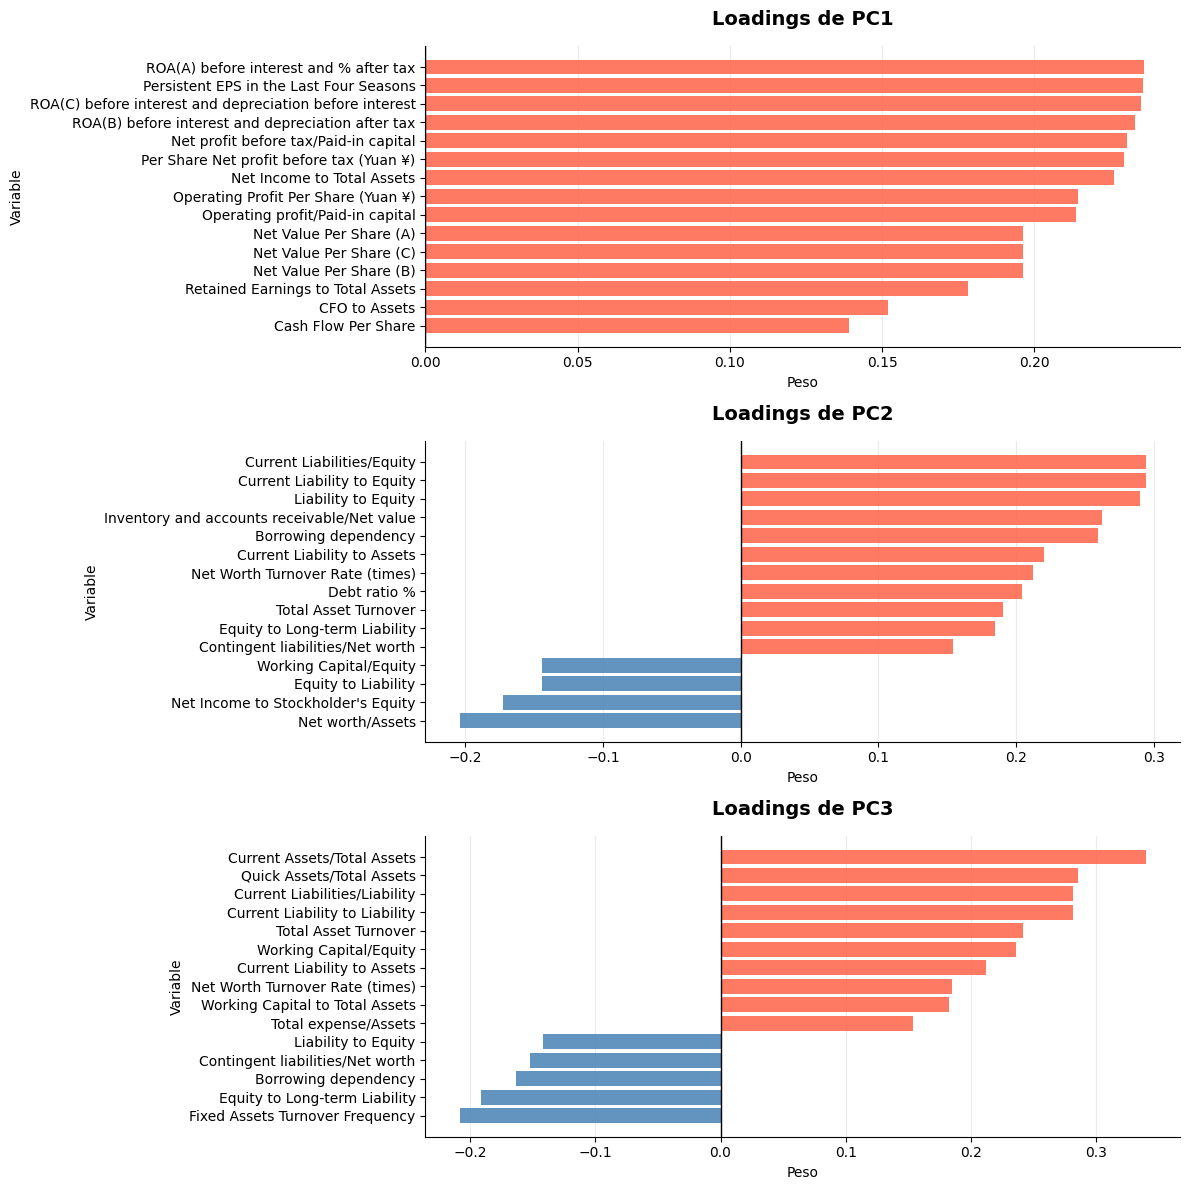

In [31]:
pcs = ["PC1", "PC2", "PC3"]
top_n = 15

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, pc in zip(axes, pcs):

    top_loadings = (loadings[pc].abs().sort_values(ascending=False).head(top_n).index)
    loadings_pc = loadings.loc[top_loadings, pc].sort_values()
    colors = ["tomato" if value > 0 else "steelblue" for value in loadings_pc.values]
    ax.barh(loadings_pc.index,loadings_pc.values,color=colors,alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)

    ax.set_title(f"Loadings de {pc}", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Peso")
    ax.set_ylabel("Variable")

    ax.grid(False)
    ax.xaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
n_80 = np.argmax(explained_var_cum >= 0.80) + 1
n_90 = np.argmax(explained_var_cum >= 0.90) + 1
n_95 = np.argmax(explained_var_cum >= 0.95) + 1

print(f"Componentes necesarios para explicar el 80% de la varianza: {n_80}")
print(f"Componentes necesarios para explicar el 90% de la varianza: {n_90}")
print(f"Componentes necesarios para explicar el 95% de la varianza: {n_95}")

Componentes necesarios para explicar el 80% de la varianza: 32
Componentes necesarios para explicar el 90% de la varianza: 43
Componentes necesarios para explicar el 95% de la varianza: 51


## 5b. DBSCAN: análisis de estructura no supervisada

DBSCAN se aplica sobre la representación PCA 2D para explorar si existen agrupaciones naturales
en los datos y si las empresas quebradas tienden a concentrarse en algún cluster.
Es un análisis puramente exploratorio: no interviene en el entrenamiento de los modelos.

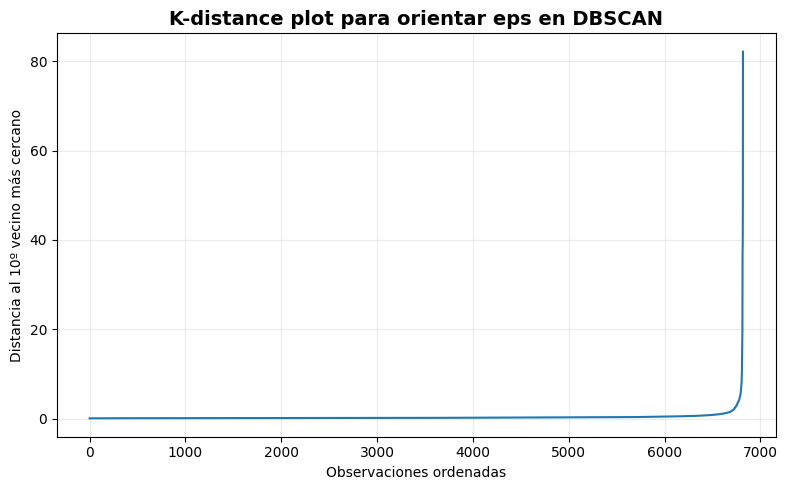

In [33]:
scaler_dbscan = StandardScaler()
X_scaled_dbscan = scaler_dbscan.fit_transform(X)

pca_dbscan = PCA(n_components=2, random_state=42)
X_pca_dbscan = pca_dbscan.fit_transform(X_scaled_dbscan)

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca_dbscan)
distances, indices = neighbors_fit.kneighbors(X_pca_dbscan)

k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances)
ax.set_title("K-distance plot para orientar eps en DBSCAN", fontsize=14, fontweight="bold")
ax.set_xlabel("Observaciones ordenadas")
ax.set_ylabel(f"Distancia al {min_samples}º vecino más cercano")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [34]:
eps = np.percentile(k_distances, 95)

modelo_dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters_dbscan = modelo_dbscan.fit_predict(X_pca_dbscan)

df_dbscan = pd.DataFrame({"PC1": X_pca_dbscan[:, 0],"PC2": X_pca_dbscan[:, 1],"Cluster": clusters_dbscan,"Bankrupt?": y.values})

n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = np.sum(clusters_dbscan == -1)

print(f"eps utilizado: {eps:.4f}")
print(f"Número de clusters detectados: {n_clusters}")
print(f"Observaciones consideradas ruido: {n_ruido}")
print(f"Porcentaje de ruido: {n_ruido / len(df_dbscan) * 100:.2f}%")

resumen_clusters = df_dbscan.groupby("Cluster").agg(n_observaciones=("Bankrupt?", "size"),n_quebradas=("Bankrupt?", "sum"),pct_quebradas=("Bankrupt?", "mean")).sort_index()

resumen_clusters["pct_quebradas"] = resumen_clusters["pct_quebradas"] * 100
resumen_clusters

eps utilizado: 0.7925
Número de clusters detectados: 2
Observaciones consideradas ruido: 226
Porcentaje de ruido: 3.31%


,n_observaciones,n_quebradas,pct_quebradas
Cluster,,,
-1,226,42,18.584071
0,6583,178,2.703934
1,10,0,0.000000


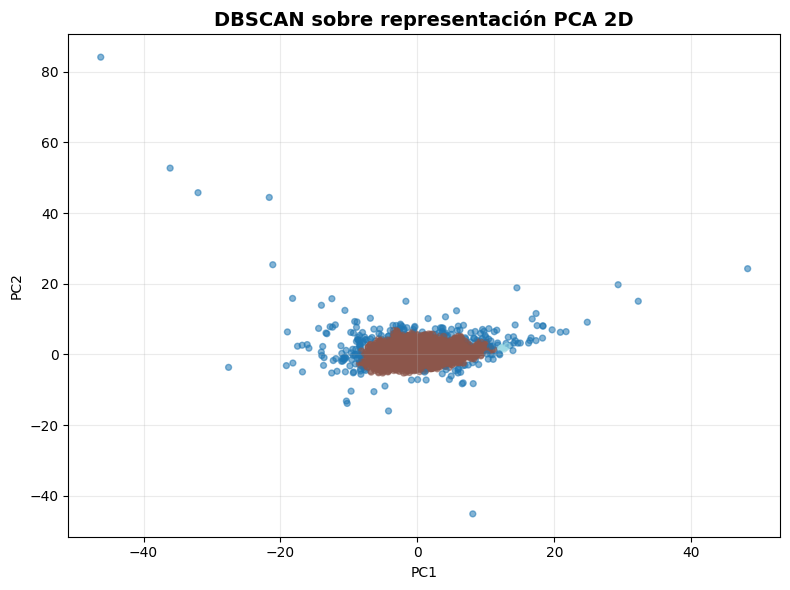

Silhouette score excluyendo ruido: 0.6563


In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_dbscan["PC1"],df_dbscan["PC2"],c=df_dbscan["Cluster"],cmap="tab20",alpha=0.55,s=18)

ax.set_title("DBSCAN sobre representación PCA 2D", fontsize=14, fontweight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

mask_no_ruido = clusters_dbscan != -1
clusters_validos = clusters_dbscan[mask_no_ruido]

if len(np.unique(clusters_validos)) >= 2:
    sil_score = silhouette_score(X_pca_dbscan[mask_no_ruido], clusters_validos)
    print(f"Silhouette score excluyendo ruido: {sil_score:.4f}")
else:
    print("No se calcula silhouette score porque no hay al menos dos clusters válidos excluyendo ruido.")

## 6. Partición train/test

Se realiza una partición 70/30 con estratificación. La estratificación mantiene en entrenamiento y test una proporción similar de empresas quebradas y no quebradas. Esto es especialmente importante en problemas desbalanceados, donde una partición aleatoria no estratificada podría dejar muy pocos casos positivos en el conjunto de test.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)


Tamaño de X_train: (4773, 93)
Tamaño de X_test: (2046, 93)


## 7. Función de evaluación

In [37]:
def evaluar_modelo(nombre_modelo, y_test, y_pred, y_proba, umbral=0.5):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    print("=" * 80)
    print(nombre_modelo)
    print("=" * 80)
    print(f"Umbral utilizado: {umbral:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test,y_pred,target_names=["No quebrada", "Quebrada"],zero_division=0))

    print("Matriz de confusión:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No quebrada", "Quebrada"])
    disp.plot(values_format="d")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.tight_layout()
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
    ax.set_title(f"Curva ROC - {nombre_modelo}", fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate / Recall")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Curva Precision-Recall
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    baseline = y_test.mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    ax.axhline(baseline, linestyle="--", label=f"Prevalencia clase positiva = {baseline:.4f}")
    ax.set_title(f"Curva Precision-Recall - {nombre_modelo}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    resultado = {"Modelo": nombre_modelo,"Umbral": umbral,"Accuracy": accuracy,"Precision": precision,"Recall": recall,"F1-score": f1,"F2-score": f2,"ROC-AUC": roc_auc,"PR-AUC": pr_auc,"Specificity": specificity}

    return resultado

**Ajuste del umbral mediante el índice de Youden**

El umbral óptimo se calcula sobre el conjunto de entrenamiento. Para ello se obtienen las probabilidades estimadas en `X_train`, se calcula la curva ROC y se selecciona el punto que maximiza el índice de Youden:

\[
J = TPR - FPR
\]

Este umbral se aplica después sobre `X_test`. De esta forma, el test se mantiene como conjunto de evaluación final y no se utiliza para elegir el punto de corte.

In [38]:
def calcular_umbral_youden(modelo, X_train, y_train):
    y_train_proba = modelo.predict_proba(X_train)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_proba)

    youden = tpr - fpr
    idx_optimo = youden.argmax()
    cutoff_optimo = thresholds[idx_optimo]

    return cutoff_optimo


def predecir_con_youden(modelo, X_train, y_train, X_test):
    cutoff_optimo = calcular_umbral_youden(modelo, X_train, y_train)

    y_test_proba = modelo.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= cutoff_optimo).astype(int)

    print(f"Cutoff óptimo Youden calculado en train: {cutoff_optimo:.4f}")

    return y_test_pred, y_test_proba, cutoff_optimo

In [39]:
resultados_modelos = []
umbrales_youden = {}

## 8. Modelo 1: Regresión logística

La regresión logística representa un baseline interpretable y conecta con la tradición probabilística iniciada por Ohlson. Aunque su estructura lineal limita la captura de relaciones complejas, ofrece una referencia clara frente a modelos más flexibles. Se utiliza `class_weight="balanced"` para compensar parcialmente el desbalance de clases sin modificar artificialmente el conjunto de datos.

Cutoff óptimo Youden calculado en train: 0.4486
Logit
Umbral utilizado: 0.4486

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.87      0.93      1980
    Quebrada       0.17      0.76      0.27        66

    accuracy                           0.87      2046
   macro avg       0.58      0.82      0.60      2046
weighted avg       0.96      0.87      0.91      2046

Matriz de confusión:
[[1730  250]
 [  16   50]]


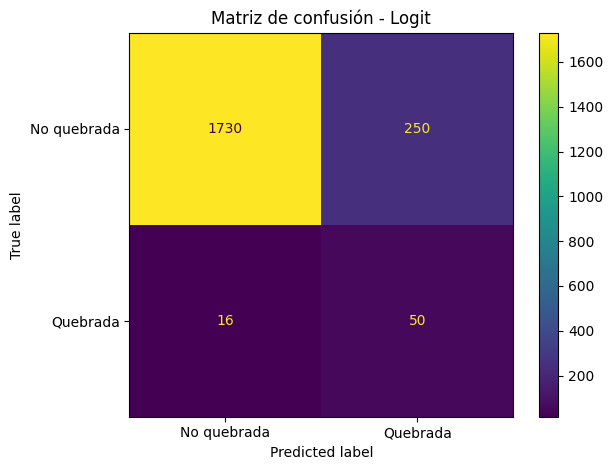

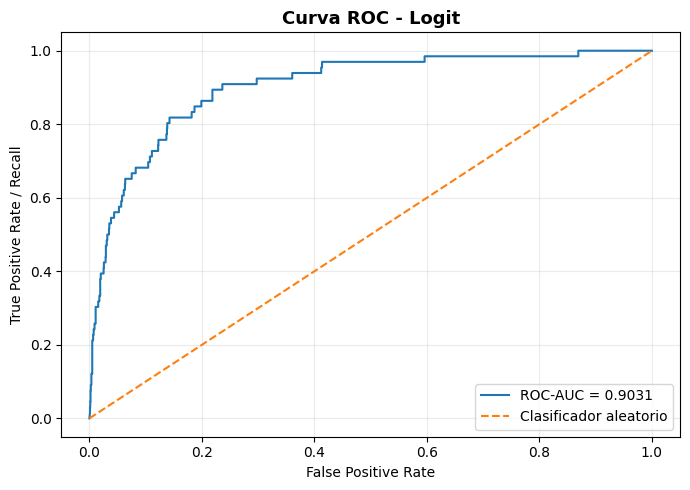

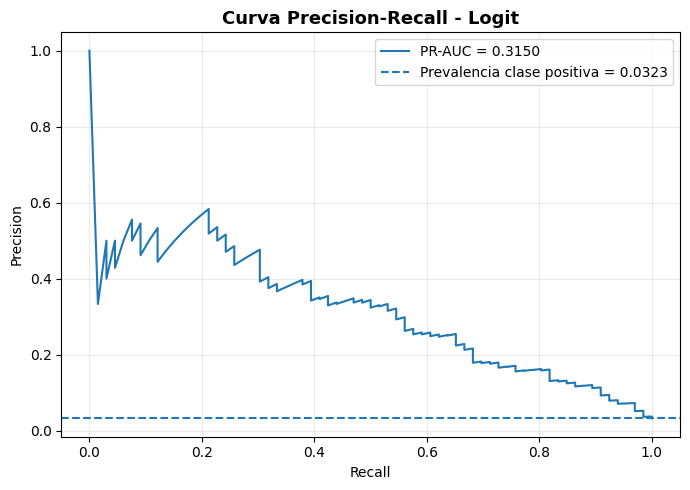

In [40]:
modelo_logit = Pipeline(steps=[("scaler", StandardScaler()),("logit", LogisticRegression(max_iter=3000,class_weight="balanced",random_state=42))])

modelo_logit.fit(X_train, y_train)

y_pred_logit, y_proba_logit, umbral_logit = predecir_con_youden(modelo_logit, X_train, y_train, X_test)
umbrales_youden["Logit"] = umbral_logit

resultado_logit = evaluar_modelo("Logit",y_test,y_pred_logit,y_proba_logit,umbral_logit)

resultados_modelos.append(resultado_logit)

## 9. Modelo 2: Regresión logística con SMOTE

En esta versión se aplica SMOTE dentro de un pipeline de `imblearn`. Es importante que SMOTE se aplique únicamente sobre el conjunto de entrenamiento. No debe aplicarse antes del `train_test_split` ni sobre el conjunto de test, porque eso introduciría fuga de información y sobrestimaría el rendimiento del modelo.

Cutoff óptimo Youden calculado en train: 0.3741
Logit + SMOTE
Umbral utilizado: 0.3741

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.89      0.94      1980
    Quebrada       0.18      0.76      0.29        66

    accuracy                           0.88      2046
   macro avg       0.59      0.82      0.62      2046
weighted avg       0.96      0.88      0.92      2046

Matriz de confusión:
[[1756  224]
 [  16   50]]


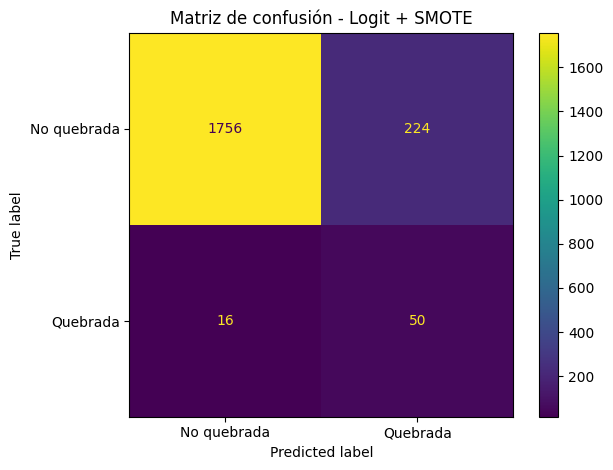

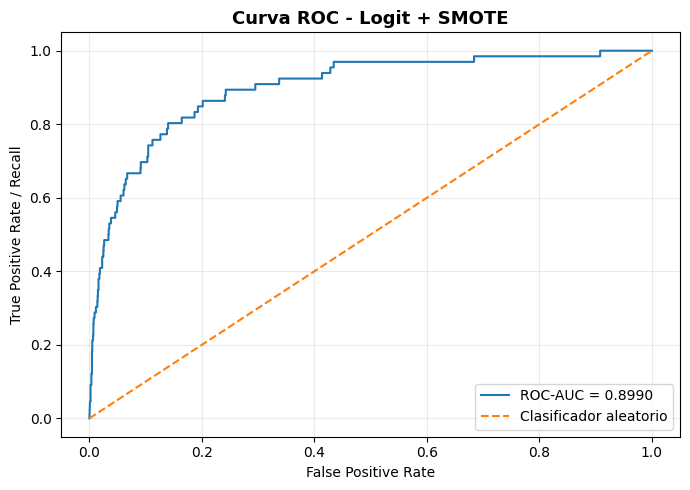

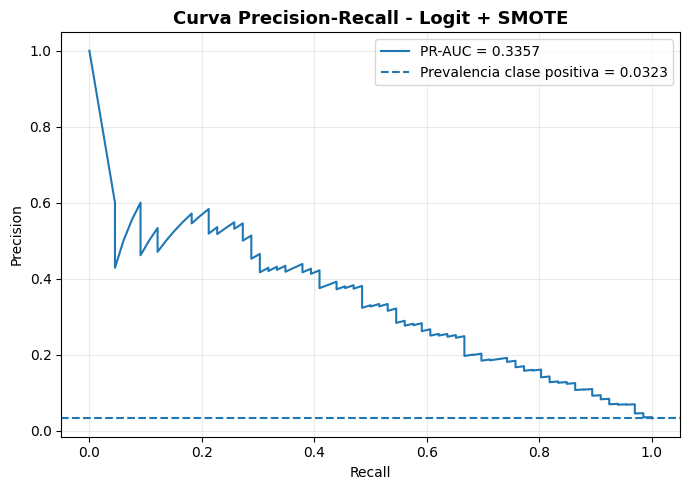

In [41]:
modelo_logit_smote = ImbPipeline(steps=[("scaler", StandardScaler()),("smote", SMOTE(sampling_strategy=0.7, random_state=42)),("logit", LogisticRegression(max_iter=3000,random_state=42))])

modelo_logit_smote.fit(X_train, y_train)

y_pred_logit_smote, y_proba_logit_smote, umbral_logit_smote = predecir_con_youden(modelo_logit_smote, X_train, y_train, X_test)
umbrales_youden["Logit + SMOTE"] = umbral_logit_smote

resultado_logit_smote = evaluar_modelo("Logit + SMOTE",y_test,y_pred_logit_smote,y_proba_logit_smote,umbral_logit_smote)

resultados_modelos.append(resultado_logit_smote)

## 10. Modelo 3: Random Forest

Random Forest se incorpora como modelo de ensamble basado en bagging. Su interés metodológico reside en que puede capturar relaciones no lineales, interacciones entre ratios financieros y patrones que un modelo lineal puede omitir. La optimización se realiza mediante `RandomizedSearchCV` con validación cruzada estratificada y un número reducido de iteraciones para mantener el análisis computacionalmente razonable.

La métrica de optimización utilizada es `average_precision`, equivalente al PR-AUC, por ser más informativa que la accuracy en contextos de clase minoritaria.

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(class_weight="balanced",random_state=42)

param_dist_rf = {"n_estimators": [100, 200, 300, 500,800],"max_depth": [None, 3, 5, 10, 15],"min_samples_split": [2, 5, 10, 20],"min_samples_leaf": [1, 2, 4, 8],"max_features": ["sqrt", "log2"]}

random_search_rf = RandomizedSearchCV(estimator=rf,param_distributions=param_dist_rf,n_iter=100,scoring="average_precision",cv=cv,random_state=42,verbose=1,return_train_score=True,n_jobs=-1)

random_search_rf.fit(X_train, y_train)

print("Mejores hiperparámetros de Random Forest:")
print(random_search_rf.best_params_)
print("\nMejor PR-AUC medio en validación cruzada:")
print(round(random_search_rf.best_score_, 4))

best_rf = random_search_rf.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores hiperparámetros de Random Forest:
{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': None}

Mejor PR-AUC medio en validación cruzada:
0.4327


**Resultados validación cruzada**

In [43]:
resultados_cv_rf = pd.DataFrame(random_search_rf.cv_results_).sort_values("rank_test_score")
resultados_cv_rf[["rank_test_score","mean_test_score","std_test_score","mean_train_score","params"]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
31,1,0.432651,0.058257,0.877706,"{'n_estimators': 500, 'min_samples_split': 20,..."
83,2,0.429785,0.058542,0.877252,"{'n_estimators': 300, 'min_samples_split': 20,..."
2,3,0.427944,0.057346,0.897431,"{'n_estimators': 500, 'min_samples_split': 2, ..."
67,4,0.427043,0.053577,0.895849,"{'n_estimators': 300, 'min_samples_split': 5, ..."
85,5,0.426622,0.057357,0.895259,"{'n_estimators': 500, 'min_samples_split': 2, ..."
91,6,0.426073,0.055999,0.870773,"{'n_estimators': 100, 'min_samples_split': 20,..."
72,7,0.424591,0.058618,0.873809,"{'n_estimators': 100, 'min_samples_split': 20,..."
96,8,0.424399,0.064683,0.893841,"{'n_estimators': 100, 'min_samples_split': 5, ..."
13,9,0.424268,0.059815,0.896094,"{'n_estimators': 300, 'min_samples_split': 5, ..."
82,9,0.424268,0.059815,0.896094,"{'n_estimators': 300, 'min_samples_split': 10,..."


Cutoff óptimo Youden calculado en train: 0.5007
Random Forest
Umbral utilizado: 0.5007

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.97      0.98      1980
    Quebrada       0.41      0.56      0.47        66

    accuracy                           0.96      2046
   macro avg       0.70      0.77      0.73      2046
weighted avg       0.97      0.96      0.96      2046

Matriz de confusión:
[[1927   53]
 [  29   37]]


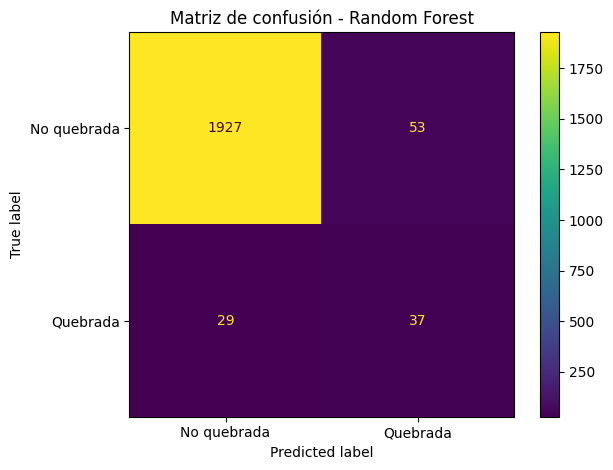

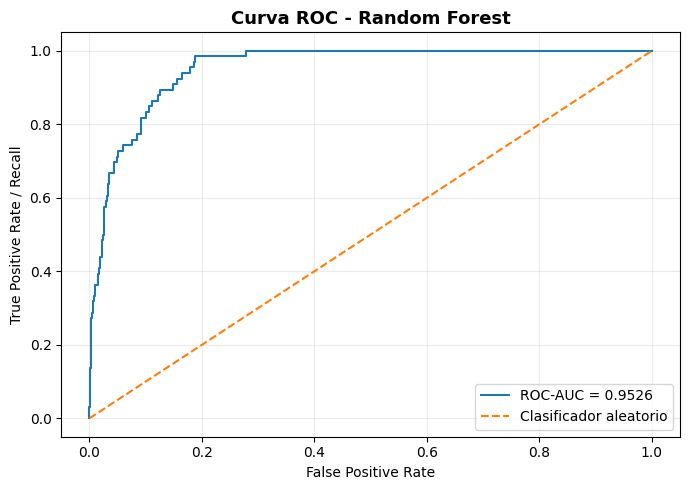

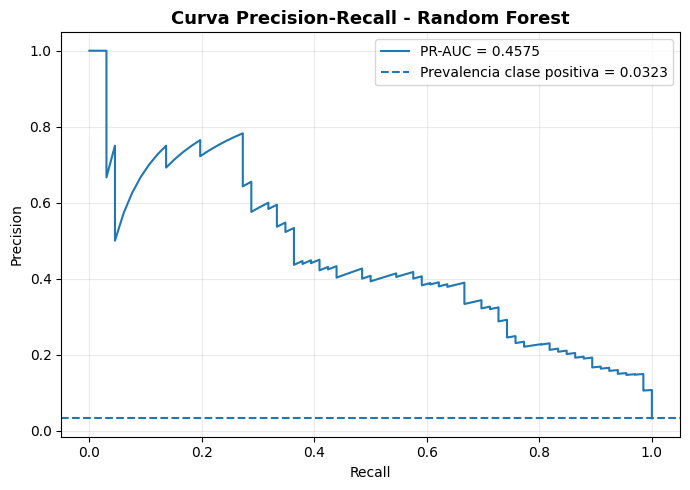

In [44]:
y_pred_rf, y_proba_rf, umbral_rf = predecir_con_youden(best_rf, X_train, y_train, X_test)
umbrales_youden["Random Forest"] = umbral_rf

resultado_rf = evaluar_modelo("Random Forest",y_test,y_pred_rf,y_proba_rf,umbral_rf)

resultados_modelos.append(resultado_rf)

## 12. Modelo 4: Random Forest con SMOTE

En esta versión se aplica SMOTE dentro del pipeline y se entrena un Random Forest con los mejores hiperparámetros encontrados previamente. Al utilizar SMOTE, no se aplica `class_weight="balanced"` para evitar una doble compensación del desbalance.

Cutoff óptimo Youden calculado en train: 0.3805
Random Forest + SMOTE
Umbral utilizado: 0.3805

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.93      0.96      1980
    Quebrada       0.26      0.76      0.39        66

    accuracy                           0.92      2046
   macro avg       0.63      0.84      0.67      2046
weighted avg       0.97      0.92      0.94      2046

Matriz de confusión:
[[1840  140]
 [  16   50]]


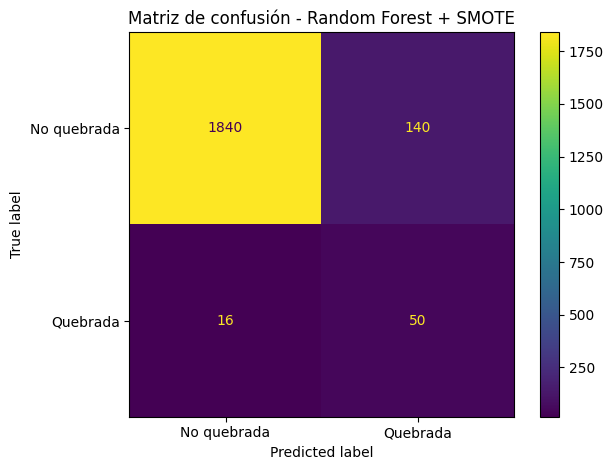

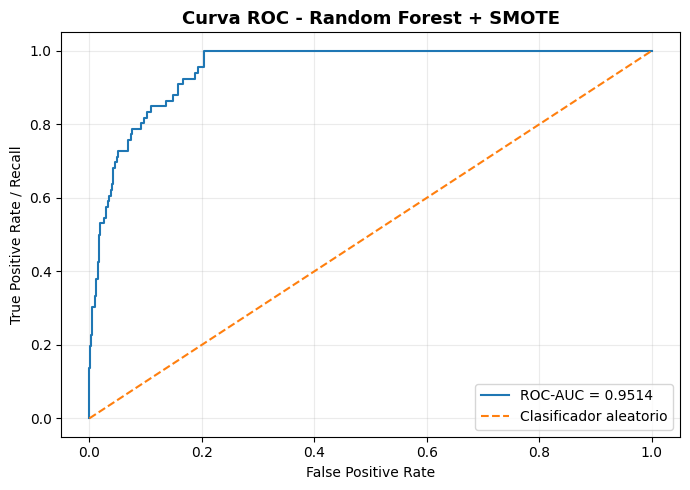

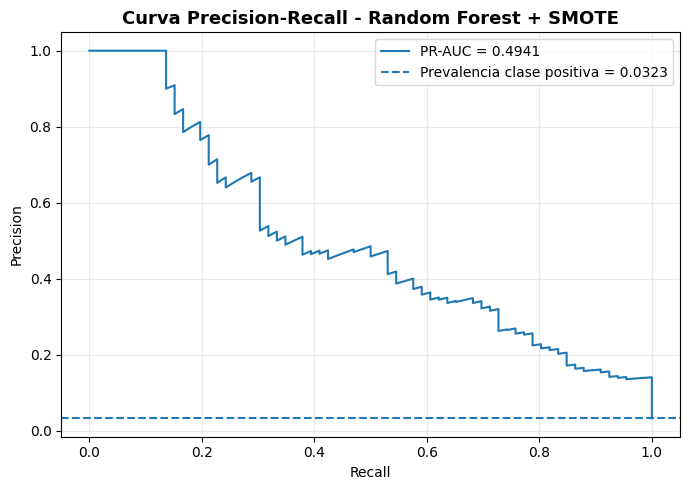

In [45]:
rf_params_smote = random_search_rf.best_params_.copy()

modelo_rf_smote = ImbPipeline(steps=[("smote", SMOTE(sampling_strategy=0.7, random_state=42)),("rf", RandomForestClassifier(**rf_params_smote,random_state=42))])

modelo_rf_smote.fit(X_train, y_train)

y_pred_rf_smote, y_proba_rf_smote, umbral_rf_smote = predecir_con_youden(modelo_rf_smote, X_train, y_train, X_test)
umbrales_youden["Random Forest + SMOTE"] = umbral_rf_smote

resultado_rf_smote = evaluar_modelo("Random Forest + SMOTE",y_test,y_pred_rf_smote,y_proba_rf_smote,umbral_rf_smote)

resultados_modelos.append(resultado_rf_smote)

## 13. Modelo 5: XGBoost

XGBoost representa una técnica de boosting basada en árboles. A diferencia de Random Forest, los árboles se construyen de forma secuencial, corrigiendo errores anteriores. Esta arquitectura suele ser competitiva en datos tabulares y permite capturar relaciones no lineales complejas. Para tratar el desbalance se utiliza `scale_pos_weight`, calculado como la razón entre observaciones no quebradas y quebradas en el conjunto de entrenamiento.

In [46]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

xgb = XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42,scale_pos_weight=scale_pos_weight)

param_dist_xgb = {"n_estimators": [100, 200, 300, 500,700],"learning_rate": [0.01, 0.05, 0.1, 0.2],"max_depth": [2, 3, 4, 5],"subsample": [0.7, 0.8, 0.9, 1.0],"colsample_bytree": [0.7, 0.8, 0.9, 1.0],"min_child_weight": [1, 3, 5, 10]}

random_search_xgb = RandomizedSearchCV(estimator=xgb,param_distributions=param_dist_xgb,n_iter=50,scoring="average_precision",cv=cv,random_state=42,verbose=1,return_train_score=True)

random_search_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros de XGBoost:")
print(random_search_xgb.best_params_)
print("\nMejor PR-AUC medio en validación cruzada:")
print(round(random_search_xgb.best_score_, 4))

best_xgb = random_search_xgb.best_estimator_

scale_pos_weight: 29.9935
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros de XGBoost:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Mejor PR-AUC medio en validación cruzada:
0.4429


**Resultados validación cruzada**

In [47]:
resultados_cv_xgb = pd.DataFrame(random_search_xgb.cv_results_).sort_values("rank_test_score")
resultados_cv_xgb[["rank_test_score","mean_test_score","std_test_score","mean_train_score","params"]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
6,1,0.442862,0.069480,1.000000,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."
31,2,0.435887,0.055144,1.000000,"{'subsample': 1.0, 'n_estimators': 700, 'min_c..."
13,3,0.423186,0.084879,1.000000,"{'subsample': 1.0, 'n_estimators': 300, 'min_c..."
4,4,0.416580,0.039761,1.000000,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
26,5,0.413934,0.044779,0.999785,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
30,6,0.413652,0.068143,1.000000,"{'subsample': 0.9, 'n_estimators': 700, 'min_c..."
12,7,0.411236,0.043182,1.000000,"{'subsample': 0.8, 'n_estimators': 500, 'min_c..."
5,8,0.410413,0.055695,1.000000,"{'subsample': 0.7, 'n_estimators': 200, 'min_c..."
1,9,0.409983,0.051969,1.000000,"{'subsample': 0.7, 'n_estimators': 500, 'min_c..."
2,10,0.409509,0.054490,1.000000,"{'subsample': 0.7, 'n_estimators': 500, 'min_c..."


Cutoff óptimo Youden calculado en train: 0.9734
XGBoost
Umbral utilizado: 0.9734

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.97      1.00      0.98      1980
    Quebrada       0.57      0.06      0.11        66

    accuracy                           0.97      2046
   macro avg       0.77      0.53      0.55      2046
weighted avg       0.96      0.97      0.96      2046

Matriz de confusión:
[[1977    3]
 [  62    4]]


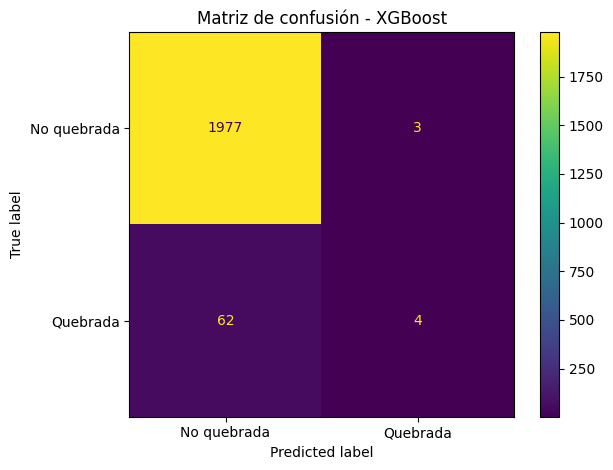

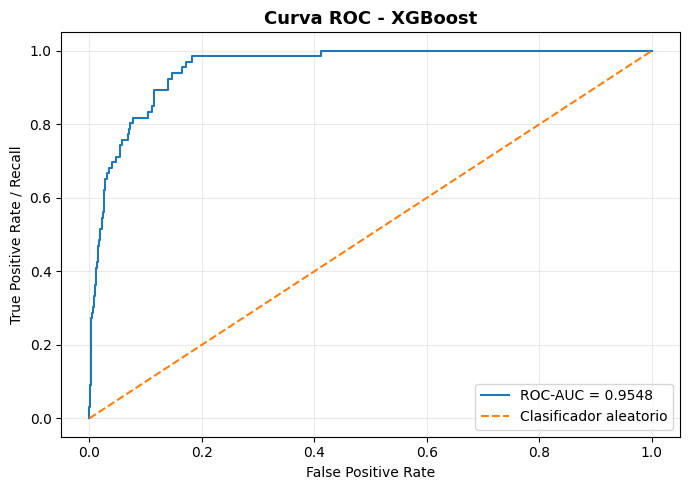

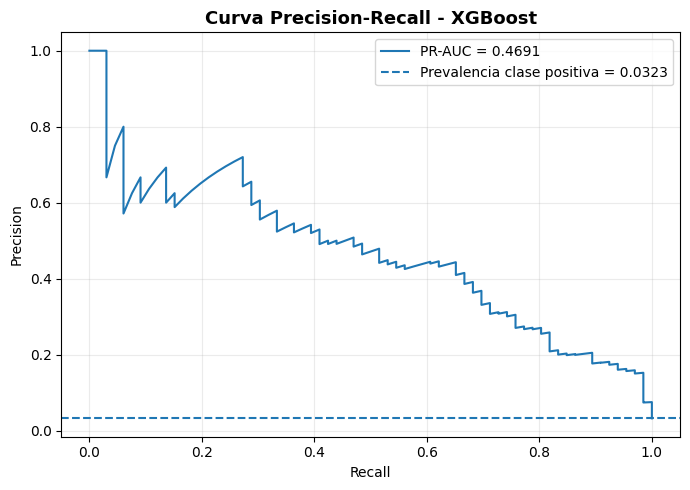

In [48]:
y_pred_xgb, y_proba_xgb, umbral_xgb = predecir_con_youden(best_xgb, X_train, y_train, X_test)
umbrales_youden["XGBoost"] = umbral_xgb

resultado_xgb = evaluar_modelo("XGBoost",y_test,y_pred_xgb,y_proba_xgb,umbral_xgb)

resultados_modelos.append(resultado_xgb)

## 14. Modelo 6: XGBoost con SMOTE

Esta versión combina SMOTE y XGBoost. Dado que SMOTE ya reequilibra el conjunto de entrenamiento, se fija `scale_pos_weight=1` para evitar una doble penalización de la clase mayoritaria.

Cutoff óptimo Youden calculado en train: 0.2798
XGBoost + SMOTE
Umbral utilizado: 0.2798

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.96      0.98      1980
    Quebrada       0.37      0.62      0.46        66

    accuracy                           0.95      2046
   macro avg       0.68      0.79      0.72      2046
weighted avg       0.97      0.95      0.96      2046

Matriz de confusión:
[[1910   70]
 [  25   41]]


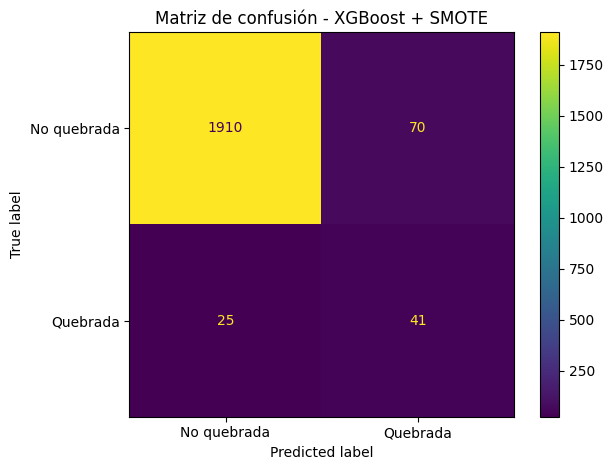

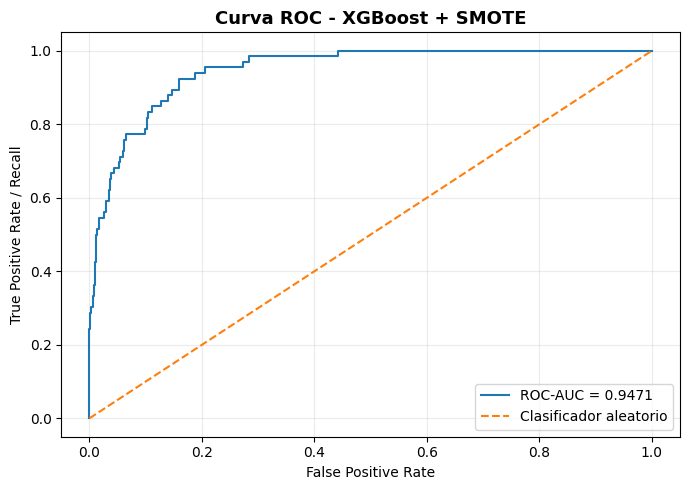

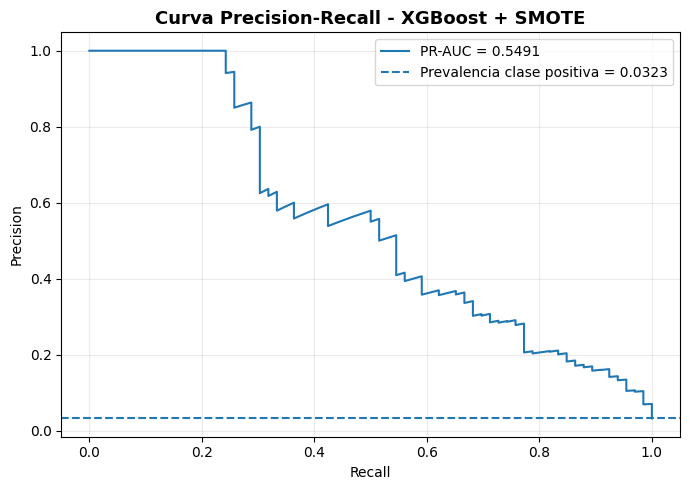

In [49]:
xgb_params_smote = random_search_xgb.best_params_.copy()

modelo_xgb_smote = ImbPipeline(steps=[("smote", SMOTE(sampling_strategy=0.7, random_state=42)),("xgb", XGBClassifier(**xgb_params_smote,objective="binary:logistic",eval_metric="logloss",random_state=42,scale_pos_weight=1))])

modelo_xgb_smote.fit(X_train, y_train)

y_pred_xgb_smote, y_proba_xgb_smote, umbral_xgb_smote = predecir_con_youden(modelo_xgb_smote, X_train, y_train, X_test)
umbrales_youden["XGBoost + SMOTE"] = umbral_xgb_smote

resultado_xgb_smote = evaluar_modelo("XGBoost + SMOTE",y_test,y_pred_xgb_smote,y_proba_xgb_smote,umbral_xgb_smote)

resultados_modelos.append(resultado_xgb_smote)

## 15. Modelos con PCA

En esta sección se repiten los mismos modelos de clasificación, pero utilizando previamente una transformación PCA. PCA se aplica una sola vez al conjunto de entrenamiento y después se reutilizan los datos transformados en todos los modelos.

El procedimiento es el siguiente: primero se escalan las variables explicativas, después se ajusta PCA solo con `X_train` y, por último, se transforma `X_train` y `X_test`. De esta forma, el conjunto de test no participa en el ajuste del escalado ni en el cálculo de los componentes principales.

In [50]:
scaler_pca_modelos = StandardScaler()

X_train_scaled_pca = scaler_pca_modelos.fit_transform(X_train)
X_test_scaled_pca = scaler_pca_modelos.transform(X_test)

pca_modelos = PCA(n_components=0.90, random_state=42)

X_train_pca = pca_modelos.fit_transform(X_train_scaled_pca)
X_test_pca = pca_modelos.transform(X_test_scaled_pca)

print("Número de componentes PCA utilizados:", pca_modelos.n_components_)
print("Varianza explicada acumulada:", round(pca_modelos.explained_variance_ratio_.sum(), 4))

Número de componentes PCA utilizados: 39
Varianza explicada acumulada: 0.9005


Para los modelos con SMOTE, primero se aplica PCA y después se realiza el sobremuestreo únicamente sobre el conjunto de entrenamiento transformado. El test se mantiene intacto durante todo el proceso.

In [51]:
smote_pca = SMOTE(sampling_strategy=0.7, random_state=42)
X_train_pca_smote, y_train_smote = smote_pca.fit_resample(X_train_pca, y_train)

print("Tamaño de X_train_pca:", X_train_pca.shape)
print("Tamaño de X_train_pca_smote:", X_train_pca_smote.shape)
print("Distribución original en train:")
print(y_train.value_counts())
print("\nDistribución tras SMOTE en train PCA:")
print(pd.Series(y_train_smote).value_counts())

Tamaño de X_train_pca: (4773, 39)
Tamaño de X_train_pca_smote: (7852, 39)
Distribución original en train:
0    4619
1     154
Name: count, dtype: int64

Distribución tras SMOTE en train PCA:
0    4619
1    3233
Name: count, dtype: int64


### 15.1. Regresión logística con PCA

Cutoff óptimo Youden calculado en train: 0.4835
Logit + PCA
Umbral utilizado: 0.4835

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.87      0.92      1980
    Quebrada       0.16      0.79      0.27        66

    accuracy                           0.86      2046
   macro avg       0.58      0.83      0.60      2046
weighted avg       0.97      0.86      0.90      2046

Matriz de confusión:
[[1713  267]
 [  14   52]]


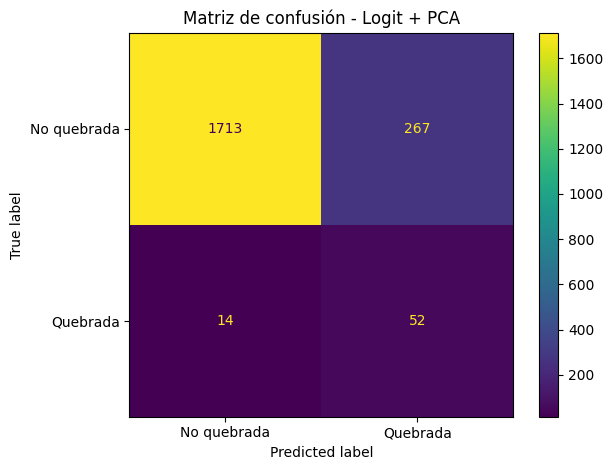

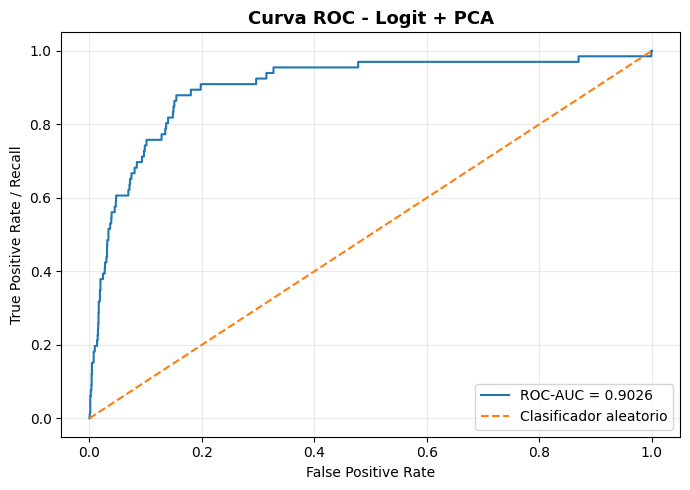

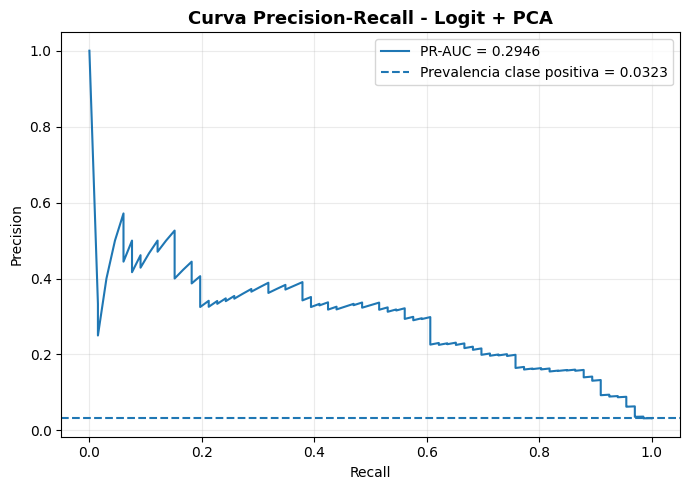

In [52]:
modelo_logit_pca = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

modelo_logit_pca.fit(X_train_pca, y_train)

y_pred_logit_pca, y_proba_logit_pca, umbral_logit_pca = predecir_con_youden(modelo_logit_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["Logit + PCA"] = umbral_logit_pca

resultado_logit_pca = evaluar_modelo("Logit + PCA",y_test,y_pred_logit_pca,y_proba_logit_pca,umbral_logit_pca)

resultado_logit_pca["PCA"] = "Sí"
resultado_logit_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_logit_pca)

### 15.2. Regresión logística con SMOTE y PCA

Cutoff óptimo Youden calculado en train: 0.4061
Logit + SMOTE + PCA
Umbral utilizado: 0.4061

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.87      0.93      1980
    Quebrada       0.16      0.74      0.26        66

    accuracy                           0.87      2046
   macro avg       0.58      0.81      0.60      2046
weighted avg       0.96      0.87      0.91      2046

Matriz de confusión:
[[1725  255]
 [  17   49]]


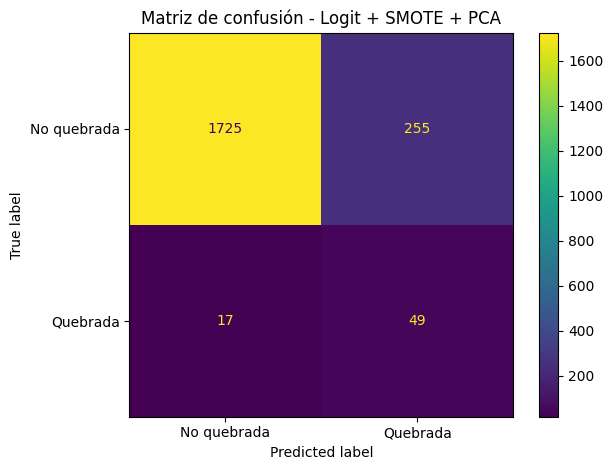

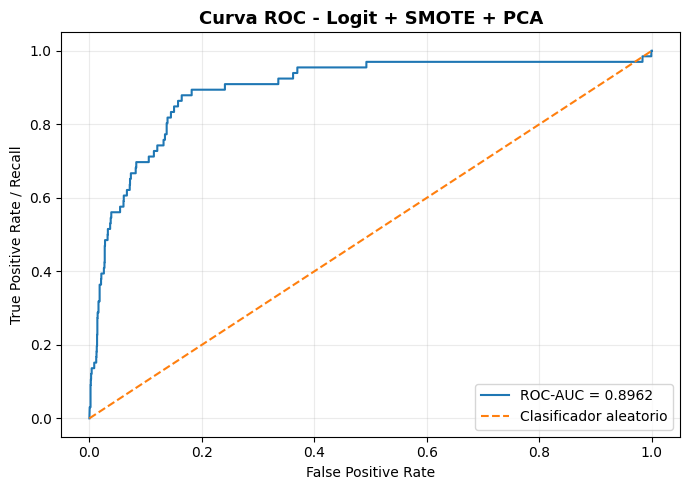

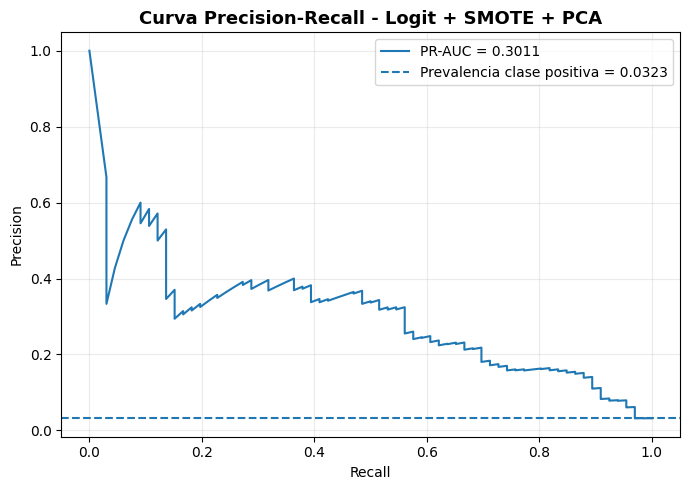

In [53]:
modelo_logit_smote_pca = LogisticRegression(max_iter=1000, random_state=42)

modelo_logit_smote_pca.fit(X_train_pca_smote, y_train_smote)

y_pred_logit_smote_pca, y_proba_logit_smote_pca, umbral_logit_smote_pca = predecir_con_youden(modelo_logit_smote_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["Logit + SMOTE + PCA"] = umbral_logit_smote_pca

resultado_logit_smote_pca = evaluar_modelo("Logit + SMOTE + PCA",y_test,y_pred_logit_smote_pca,y_proba_logit_smote_pca,umbral_logit_smote_pca)

resultado_logit_smote_pca["PCA"] = "Sí"
resultado_logit_smote_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_logit_smote_pca)

### 15.3. Random Forest con PCA

Cutoff óptimo Youden calculado en train: 0.5040
Random Forest + PCA
Umbral utilizado: 0.5040

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.98      0.99      0.98      1980
    Quebrada       0.44      0.35      0.39        66

    accuracy                           0.96      2046
   macro avg       0.71      0.67      0.69      2046
weighted avg       0.96      0.96      0.96      2046

Matriz de confusión:
[[1951   29]
 [  43   23]]


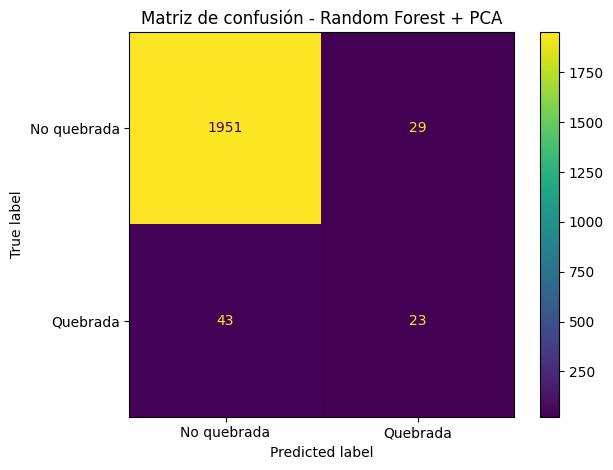

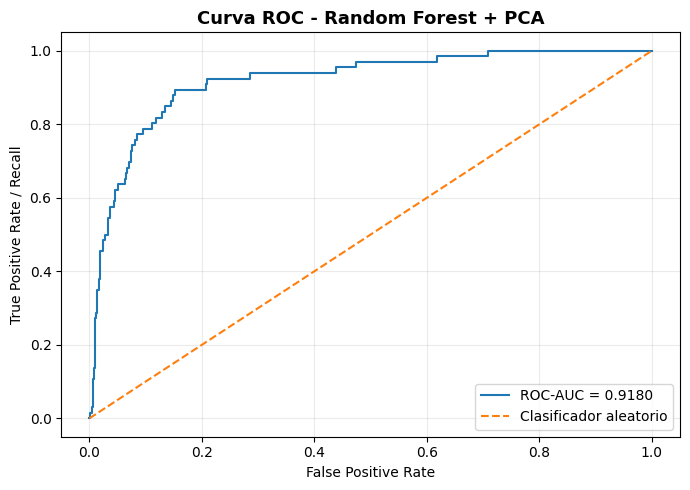

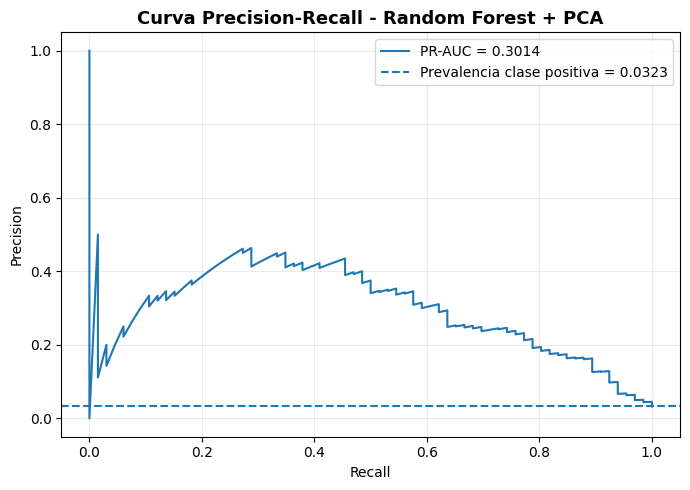

In [54]:
rf_params_pca = random_search_rf.best_params_.copy()

modelo_rf_pca = RandomForestClassifier(**rf_params_pca,class_weight="balanced",random_state=42)

modelo_rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca, y_proba_rf_pca, umbral_rf_pca = predecir_con_youden(modelo_rf_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["Random Forest + PCA"] = umbral_rf_pca

resultado_rf_pca = evaluar_modelo("Random Forest + PCA",y_test,y_pred_rf_pca,y_proba_rf_pca,umbral_rf_pca)

resultado_rf_pca["PCA"] = "Sí"
resultado_rf_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_rf_pca)

### 15.4. Random Forest con SMOTE y PCA

Cutoff óptimo Youden calculado en train: 0.4523
Random Forest + SMOTE + PCA
Umbral utilizado: 0.4523

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.98      0.95      0.97      1980
    Quebrada       0.26      0.56      0.35        66

    accuracy                           0.93      2046
   macro avg       0.62      0.75      0.66      2046
weighted avg       0.96      0.93      0.95      2046

Matriz de confusión:
[[1874  106]
 [  29   37]]


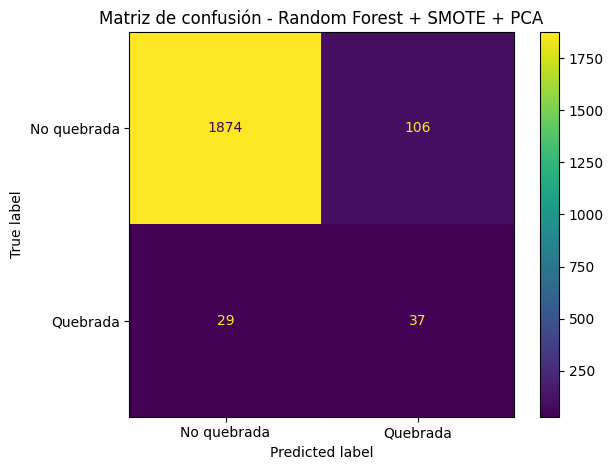

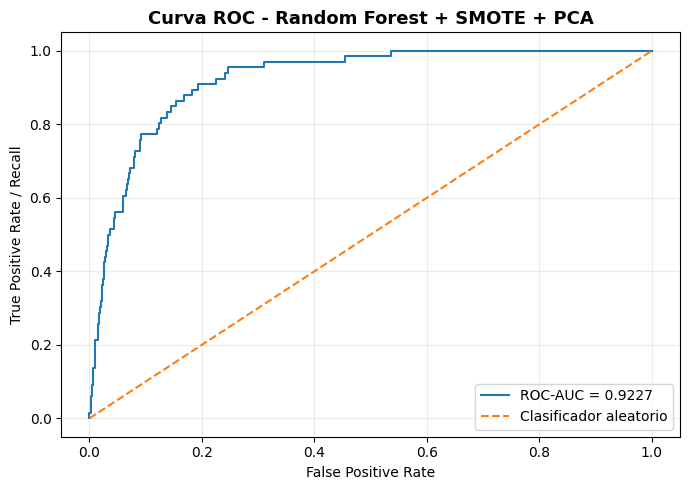

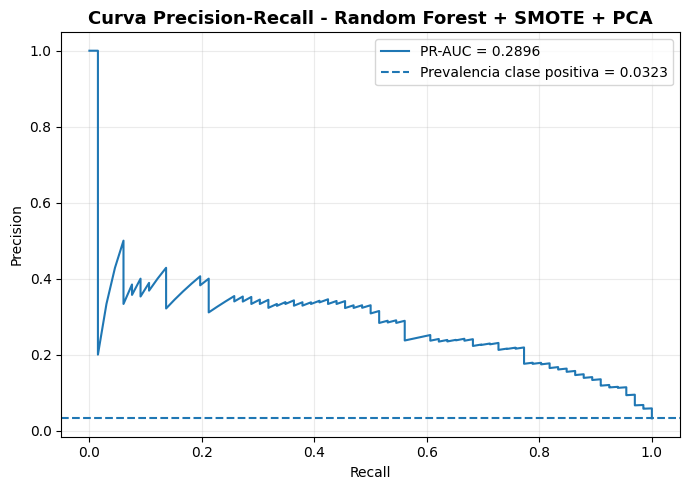

In [55]:
modelo_rf_smote_pca = RandomForestClassifier(**rf_params_smote,random_state=42)

modelo_rf_smote_pca.fit(X_train_pca_smote, y_train_smote)

y_pred_rf_smote_pca, y_proba_rf_smote_pca, umbral_rf_smote_pca = predecir_con_youden(modelo_rf_smote_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["Random Forest + SMOTE + PCA"] = umbral_rf_smote_pca

resultado_rf_smote_pca = evaluar_modelo("Random Forest + SMOTE + PCA",y_test,y_pred_rf_smote_pca,y_proba_rf_smote_pca,umbral_rf_smote_pca)

resultado_rf_smote_pca["PCA"] = "Sí"
resultado_rf_smote_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_rf_smote_pca)

### 15.5. XGBoost con PCA

Cutoff óptimo Youden calculado en train: 0.9645
XGBoost + PCA
Umbral utilizado: 0.9645

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.97      1.00      0.98      1980
    Quebrada       0.67      0.03      0.06        66

    accuracy                           0.97      2046
   macro avg       0.82      0.51      0.52      2046
weighted avg       0.96      0.97      0.95      2046

Matriz de confusión:
[[1979    1]
 [  64    2]]


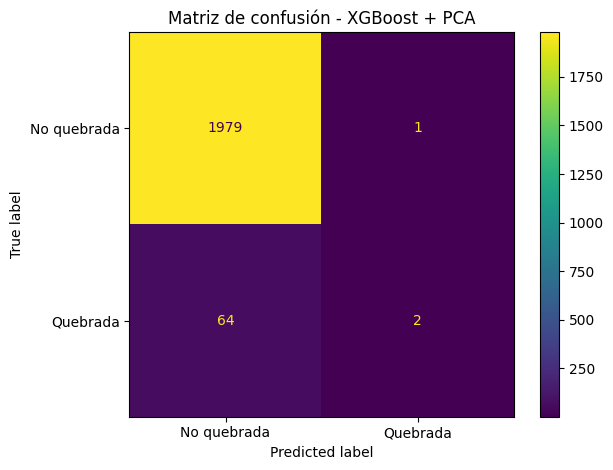

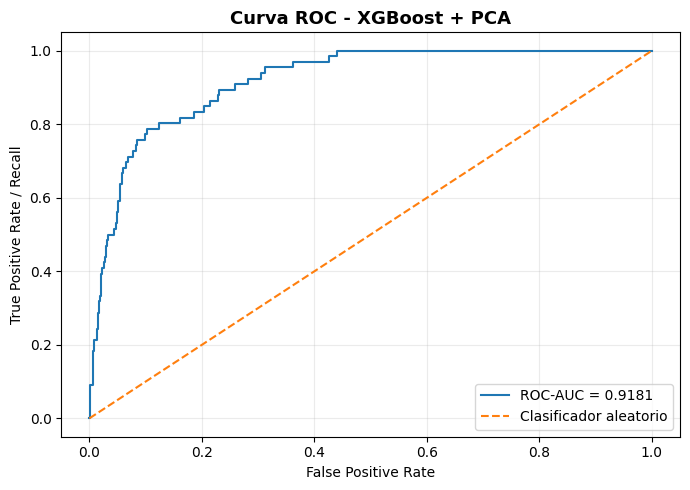

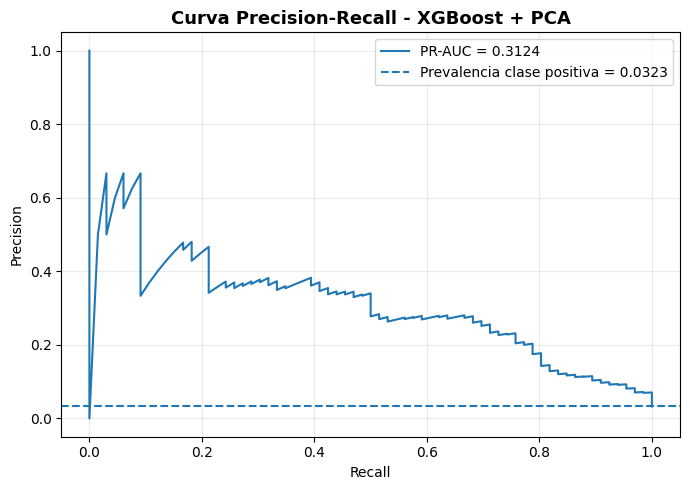

In [56]:
xgb_params_pca = random_search_xgb.best_params_.copy()

modelo_xgb_pca = XGBClassifier(**xgb_params_pca,objective="binary:logistic",eval_metric="logloss",random_state=42,scale_pos_weight=scale_pos_weight)

modelo_xgb_pca.fit(X_train_pca, y_train)

y_pred_xgb_pca, y_proba_xgb_pca, umbral_xgb_pca = predecir_con_youden(modelo_xgb_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["XGBoost + PCA"] = umbral_xgb_pca

resultado_xgb_pca = evaluar_modelo("XGBoost + PCA",y_test,y_pred_xgb_pca,y_proba_xgb_pca,umbral_xgb_pca)

resultado_xgb_pca["PCA"] = "Sí"
resultado_xgb_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_xgb_pca)

### 15.6. XGBoost con SMOTE y PCA

Cutoff óptimo Youden calculado en train: 0.7513
XGBoost + SMOTE + PCA
Umbral utilizado: 0.7513

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.98      0.98      0.98      1980
    Quebrada       0.39      0.35      0.37        66

    accuracy                           0.96      2046
   macro avg       0.68      0.67      0.67      2046
weighted avg       0.96      0.96      0.96      2046

Matriz de confusión:
[[1944   36]
 [  43   23]]


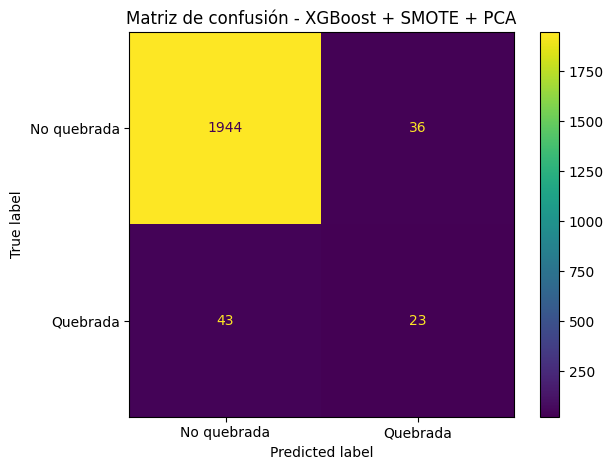

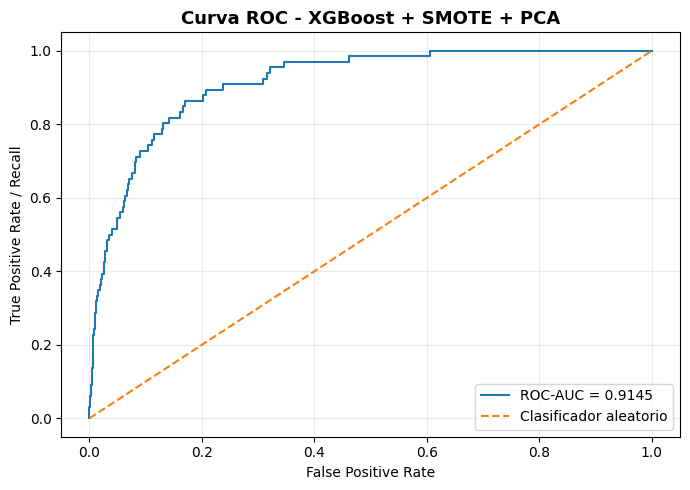

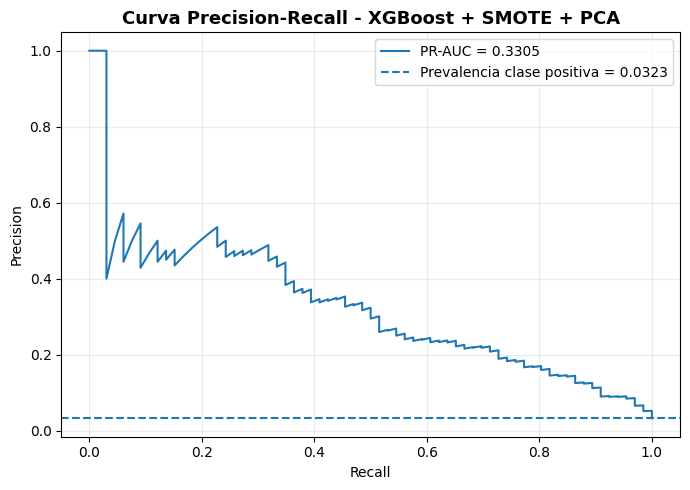

In [57]:
modelo_xgb_smote_pca = XGBClassifier(**xgb_params_smote,objective="binary:logistic",eval_metric="logloss",random_state=42,scale_pos_weight=1)

modelo_xgb_smote_pca.fit(X_train_pca_smote, y_train_smote)

y_pred_xgb_smote_pca, y_proba_xgb_smote_pca, umbral_xgb_smote_pca = predecir_con_youden(modelo_xgb_smote_pca,X_train_pca,y_train,X_test_pca)

umbrales_youden["XGBoost + SMOTE + PCA"] = umbral_xgb_smote_pca

resultado_xgb_smote_pca = evaluar_modelo("XGBoost + SMOTE + PCA",y_test,y_pred_xgb_smote_pca,y_proba_xgb_smote_pca,umbral_xgb_smote_pca)

resultado_xgb_smote_pca["PCA"] = "Sí"
resultado_xgb_smote_pca["N componentes PCA"] = pca_modelos.n_components_

resultados_modelos.append(resultado_xgb_smote_pca)

Con este bloque se obtiene una versión con PCA de cada uno de los modelos principales del notebook. La comparación final permite observar si la reducción de dimensionalidad mejora el rendimiento o si, por el contrario, se pierde información relevante para detectar la clase minoritaria.

## Youden cross-validated out-of-sample

In [58]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve
import numpy as np

cv_youden_oof = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

def calcular_umbral_youden_oof(modelo, X_train, y_train, cv=cv_youden_oof):

    y_proba_oof = cross_val_predict(clone(modelo),X_train,y_train,cv=cv,method="predict_proba",n_jobs=-1)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_train, y_proba_oof)

    youden = tpr - fpr
    idx_optimo = np.argmax(youden)
    umbral_optimo = thresholds[idx_optimo]

    return umbral_optimo, y_proba_oof


def predecir_con_youden_oof(modelo, X_train, y_train, X_test, cv=cv_youden_oof):

    umbral_optimo, y_proba_oof = calcular_umbral_youden_oof(modelo,X_train,y_train,cv=cv)

    modelo_final = clone(modelo)
    modelo_final.fit(X_train, y_train)

    y_test_proba = modelo_final.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= umbral_optimo).astype(int)

    print(f"Cutoff óptimo Youden cross-validated out-of-sample: {umbral_optimo:.4f}")

    return y_test_pred, y_test_proba, umbral_optimo, modelo_final

Cutoff óptimo Youden cross-validated out-of-sample: 0.5155
Logit + Youden OOS
Umbral utilizado: 0.5155

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.89      0.94      1980
    Quebrada       0.18      0.70      0.29        66

    accuracy                           0.89      2046
   macro avg       0.58      0.80      0.61      2046
weighted avg       0.96      0.89      0.92      2046

Matriz de confusión:
[[1771  209]
 [  20   46]]


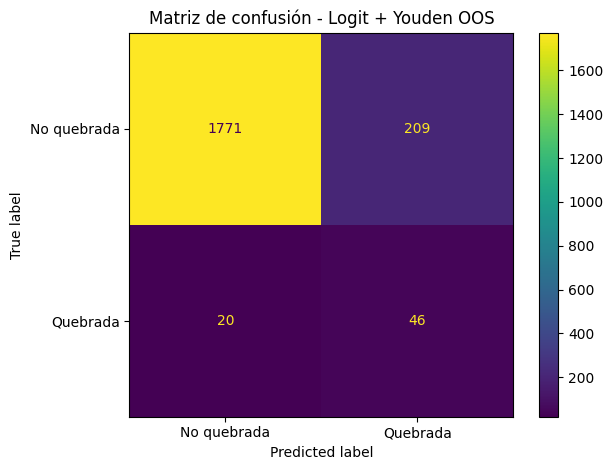

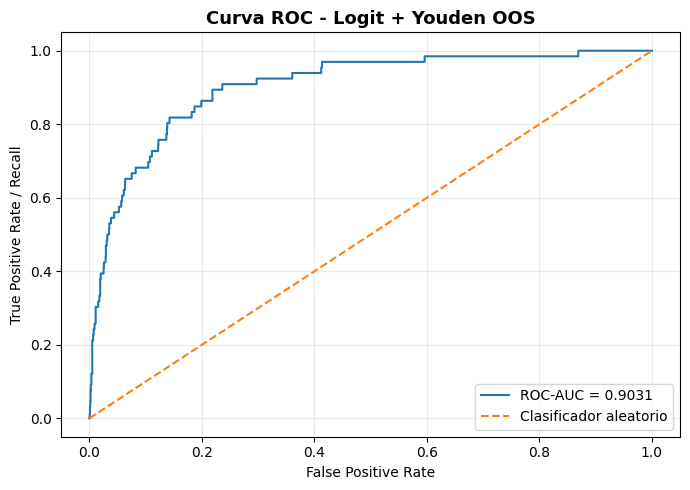

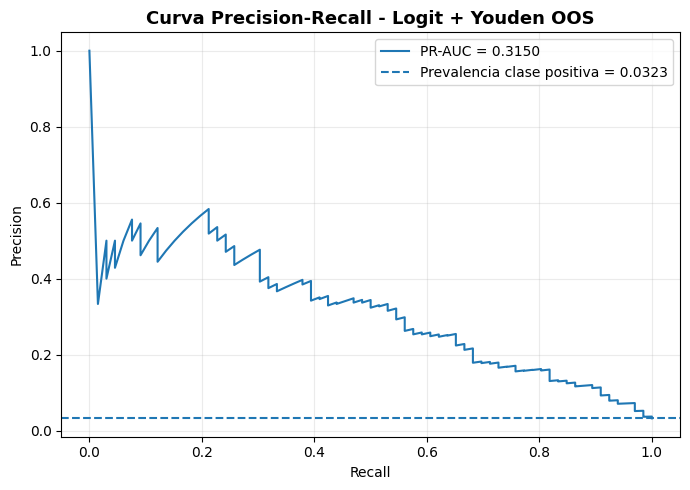

Cutoff óptimo Youden cross-validated out-of-sample: 0.4323
Logit + SMOTE + Youden OOS
Umbral utilizado: 0.4323

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.90      0.94      1980
    Quebrada       0.19      0.70      0.30        66

    accuracy                           0.89      2046
   macro avg       0.59      0.80      0.62      2046
weighted avg       0.96      0.89      0.92      2046

Matriz de confusión:
[[1784  196]
 [  20   46]]


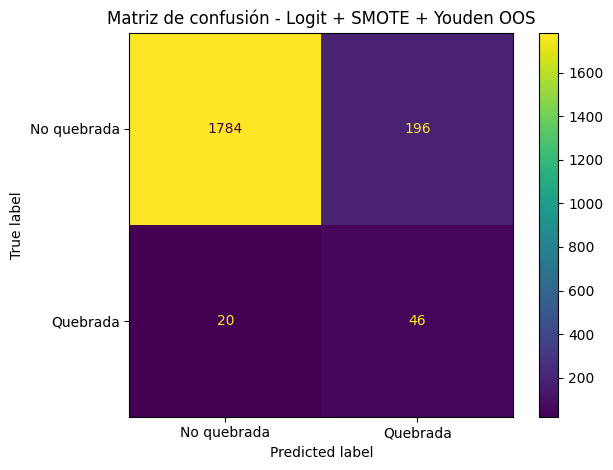

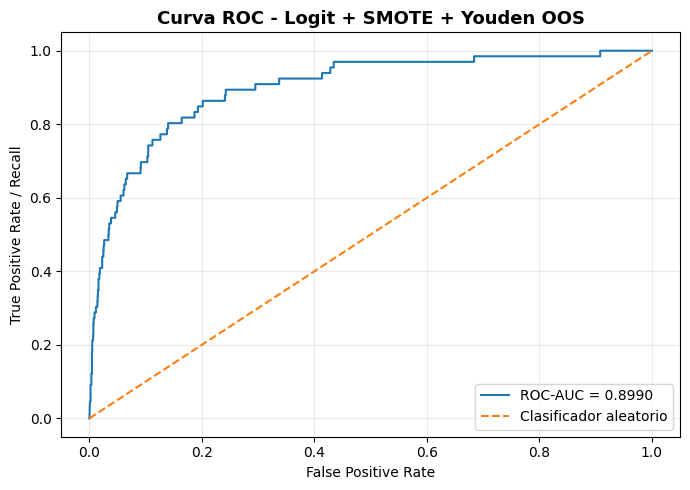

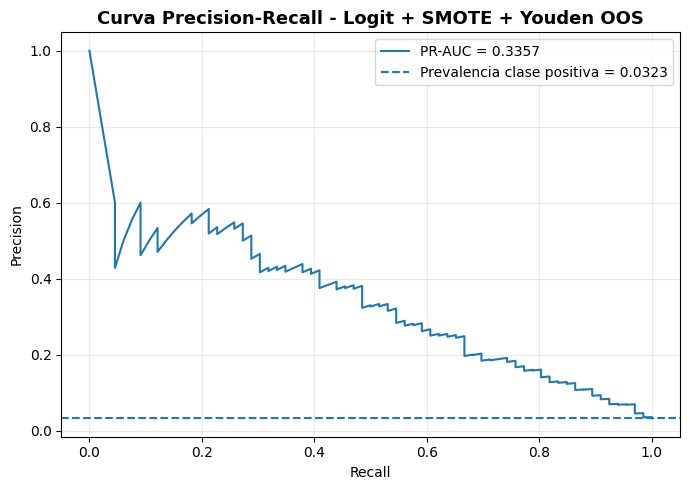

Cutoff óptimo Youden cross-validated out-of-sample: 0.1569
Random Forest + Youden OOS
Umbral utilizado: 0.1569

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.89      0.94      1980
    Quebrada       0.21      0.85      0.33        66

    accuracy                           0.89      2046
   macro avg       0.60      0.87      0.64      2046
weighted avg       0.97      0.89      0.92      2046

Matriz de confusión:
[[1764  216]
 [  10   56]]


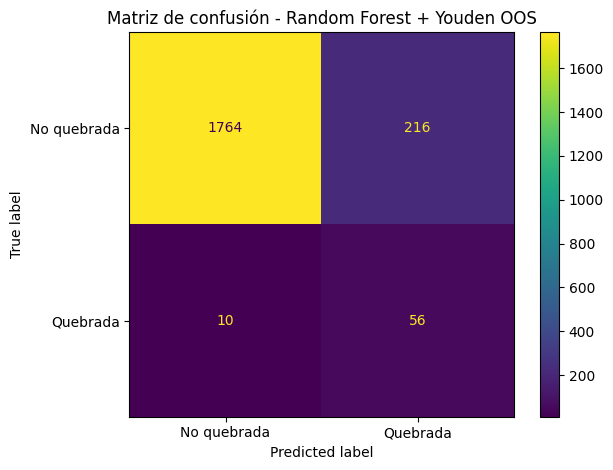

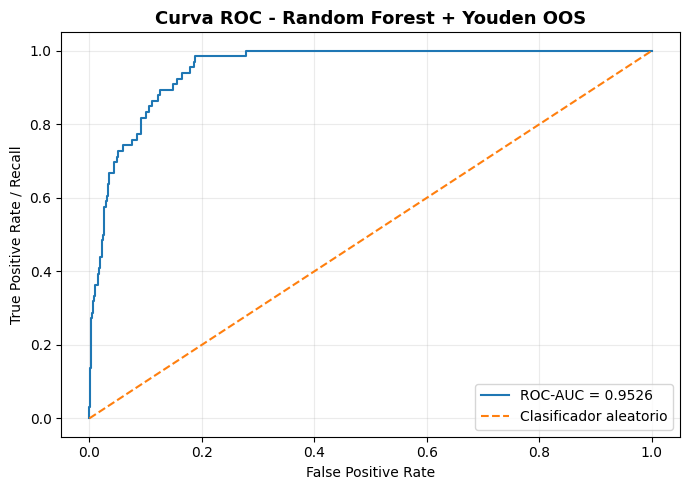

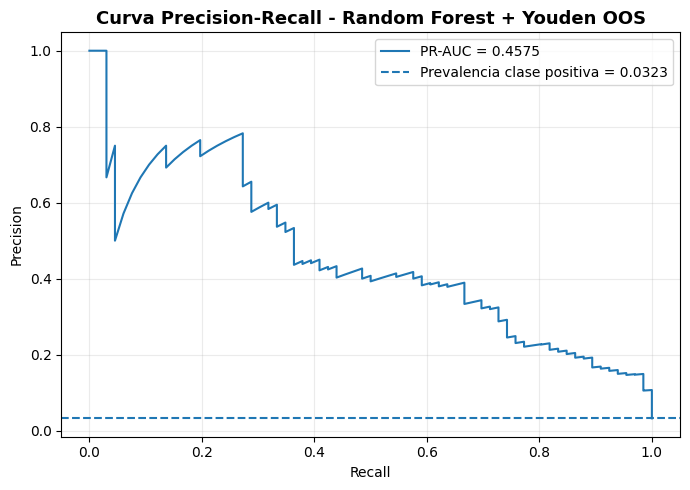

Cutoff óptimo Youden cross-validated out-of-sample: 0.2829
Random Forest + SMOTE + Youden OOS
Umbral utilizado: 0.2829

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.90      0.95      1980
    Quebrada       0.22      0.80      0.34        66

    accuracy                           0.90      2046
   macro avg       0.60      0.85      0.64      2046
weighted avg       0.97      0.90      0.93      2046

Matriz de confusión:
[[1788  192]
 [  13   53]]


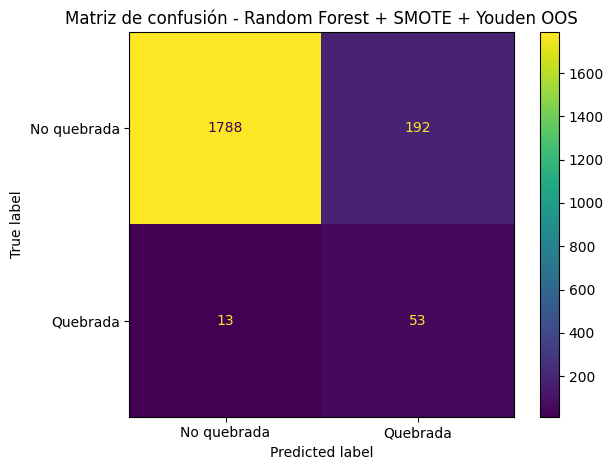

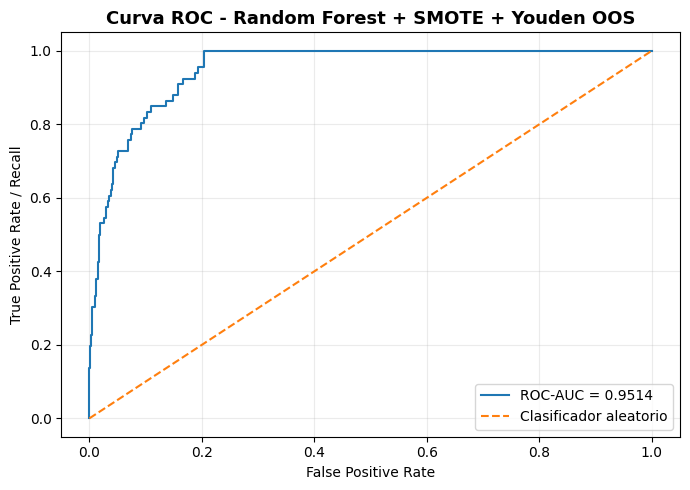

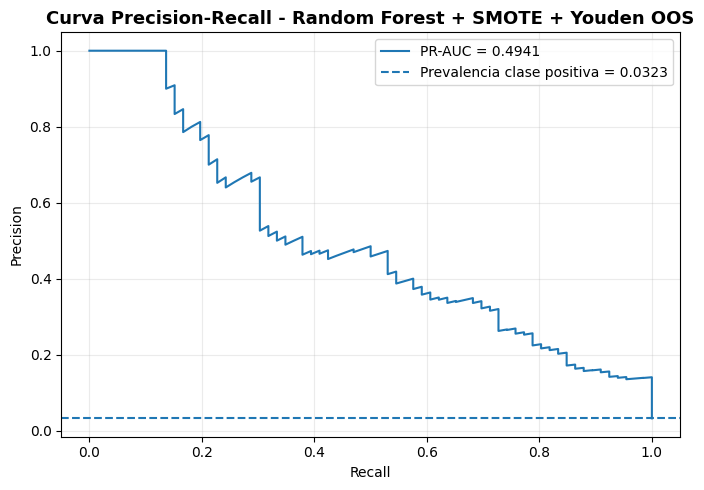

Cutoff óptimo Youden cross-validated out-of-sample: 0.0124
XGBoost + Youden OOS
Umbral utilizado: 0.0124

Classification report:
              precision    recall  f1-score   support

 No quebrada       1.00      0.86      0.92      1980
    Quebrada       0.18      0.92      0.30        66

    accuracy                           0.86      2046
   macro avg       0.59      0.89      0.61      2046
weighted avg       0.97      0.86      0.90      2046

Matriz de confusión:
[[1703  277]
 [   5   61]]


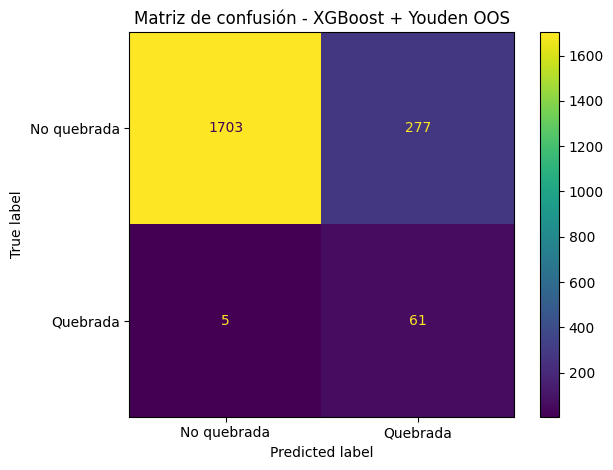

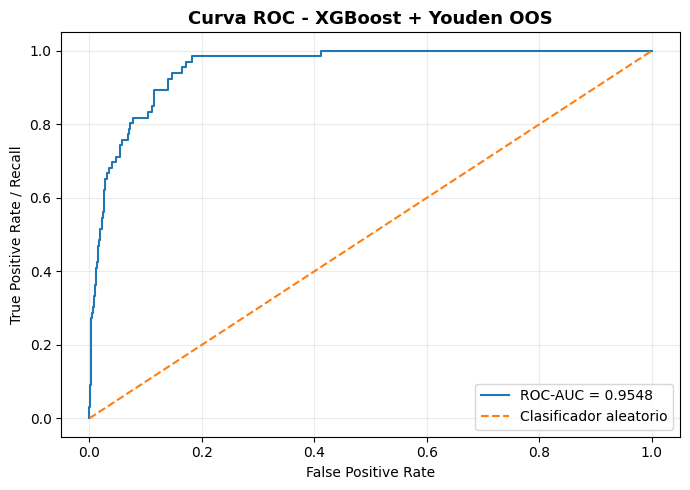

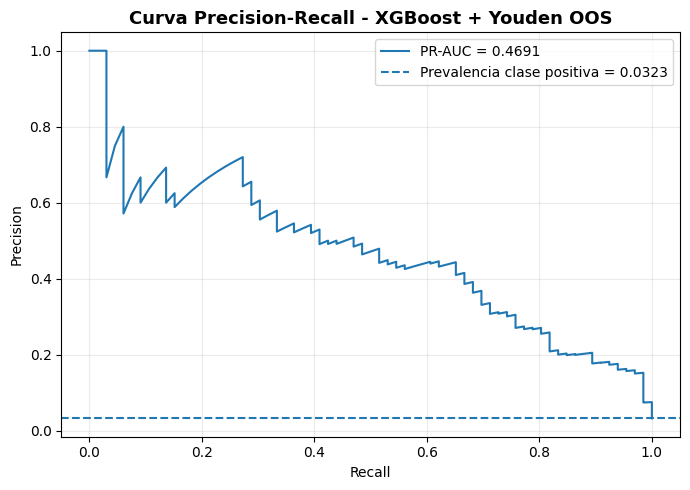

Cutoff óptimo Youden cross-validated out-of-sample: 0.0452
XGBoost + SMOTE + Youden OOS
Umbral utilizado: 0.0452

Classification report:
              precision    recall  f1-score   support

 No quebrada       0.99      0.90      0.95      1980
    Quebrada       0.21      0.77      0.33        66

    accuracy                           0.90      2046
   macro avg       0.60      0.84      0.64      2046
weighted avg       0.97      0.90      0.93      2046

Matriz de confusión:
[[1787  193]
 [  15   51]]


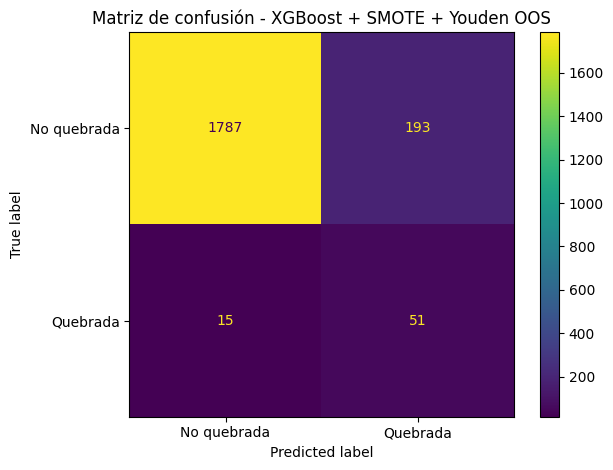

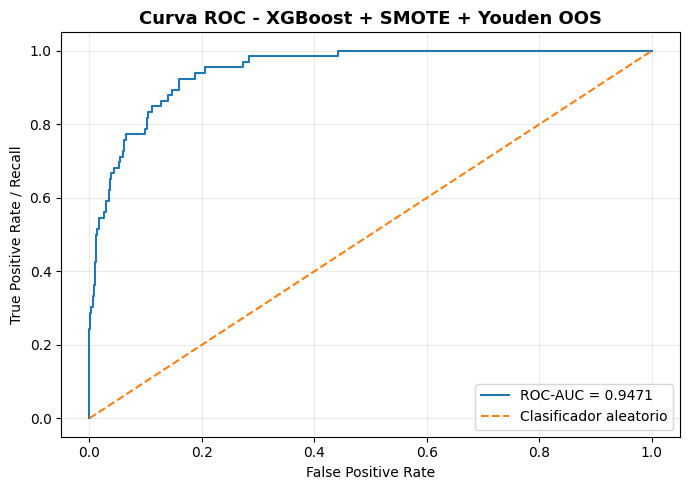

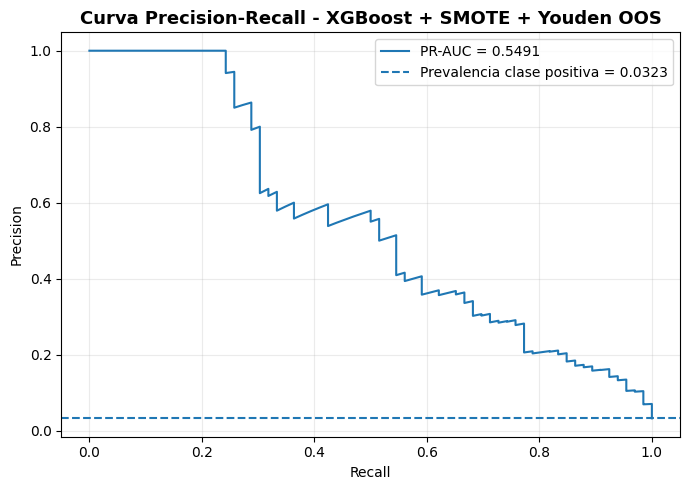

In [59]:
resultados_modelos_oof = []
umbrales_youden_oof = {}
modelos_finales_oof = {}

modelos_oof = {"Logit + Youden OOS": modelo_logit,"Logit + SMOTE + Youden OOS": modelo_logit_smote,"Random Forest + Youden OOS": best_rf,"Random Forest + SMOTE + Youden OOS": modelo_rf_smote,"XGBoost + Youden OOS": best_xgb,"XGBoost + SMOTE + Youden OOS": modelo_xgb_smote}

for nombre_modelo, modelo in modelos_oof.items():

    y_pred_oof, y_proba_oof, umbral_oof, modelo_final_oof = predecir_con_youden_oof(modelo,X_train,y_train,X_test)

    umbrales_youden_oof[nombre_modelo] = umbral_oof
    modelos_finales_oof[nombre_modelo] = modelo_final_oof

    resultado_oof = evaluar_modelo(nombre_modelo,y_test,y_pred_oof,y_proba_oof,umbral_oof)

    resultado_oof["Tipo Youden"] = "Cross-validated out-of-sample"
    resultado_oof["PCA"] = "No"
    resultado_oof["N componentes PCA"] = "-"

    resultados_modelos_oof.append(resultado_oof)
    resultados_modelos.append(resultado_oof)

In [60]:
comparacion_youden = pd.DataFrame(resultados_modelos)

if "Tipo Youden" not in comparacion_youden.columns:
    comparacion_youden["Tipo Youden"] = "In-sample"

comparacion_youden["Tipo Youden"] = comparacion_youden["Tipo Youden"].fillna("In-sample")

modelos_comparacion_youden = ["Logit","Logit + Youden OOS","Logit + SMOTE","Logit + SMOTE + Youden OOS","Random Forest","Random Forest + Youden OOS","Random Forest + SMOTE","Random Forest + SMOTE + Youden OOS","XGBoost","XGBoost + Youden OOS","XGBoost + SMOTE","XGBoost + SMOTE + Youden OOS"]

comparacion_youden = comparacion_youden[comparacion_youden["Modelo"].isin(modelos_comparacion_youden)].copy()

comparacion_youden = comparacion_youden[
    ["Modelo","Tipo Youden","Umbral","Accuracy","Precision","Recall","F2-score","ROC-AUC","PR-AUC","Specificity",]
].sort_values("PR-AUC", ascending=False)

comparacion_youden.round(4)

,Modelo,Tipo Youden,Umbral,Accuracy,Precision,Recall,F2-score,ROC-AUC,PR-AUC,Specificity
17,XGBoost + SMOTE + Youden OOS,Cross-validated out-of-sample,0.0452,0.8983,0.2090,0.7727,0.5020,0.9471,0.5491,0.9025
5,XGBoost + SMOTE,In-sample,0.2798,0.9536,0.3694,0.6212,0.5467,0.9471,0.5491,0.9646
3,Random Forest + SMOTE,In-sample,0.3805,0.9238,0.2632,0.7576,0.5507,0.9514,0.4941,0.9293
15,Random Forest + SMOTE + Youden OOS,Cross-validated out-of-sample,0.2829,0.8998,0.2163,0.8030,0.5206,0.9514,0.4941,0.9030
16,XGBoost + Youden OOS,Cross-validated out-of-sample,0.0124,0.8622,0.1805,0.9242,0.5066,0.9548,0.4691,0.8601
4,XGBoost,In-sample,0.9734,0.9682,0.5714,0.0606,0.0738,0.9548,0.4691,0.9985
2,Random Forest,In-sample,0.5007,0.9599,0.4111,0.5606,0.5226,0.9526,0.4575,0.9732
14,Random Forest + Youden OOS,Cross-validated out-of-sample,0.1569,0.8895,0.2059,0.8485,0.5224,0.9526,0.4575,0.8909
13,Logit + SMOTE + Youden OOS,Cross-validated out-of-sample,0.4323,0.8944,0.1901,0.6970,0.4545,0.8990,0.3357,0.9010
1,Logit + SMOTE,In-sample,0.3741,0.8827,0.1825,0.7576,0.4647,0.8990,0.3357,0.8869


In [61]:
pares_youden = [("Logit", "Logit + Youden OOS"),("Logit + SMOTE", "Logit + SMOTE + Youden OOS"),("Random Forest", "Random Forest + Youden OOS"),("Random Forest + SMOTE", "Random Forest + SMOTE + Youden OOS"),("XGBoost", "XGBoost + Youden OOS"),("XGBoost + SMOTE", "XGBoost + SMOTE + Youden OOS")]

for modelo_insample, modelo_oof in pares_youden:

    fila_in = comparacion_youden[comparacion_youden["Modelo"] == modelo_insample]
    fila_oof = comparacion_youden[comparacion_youden["Modelo"] == modelo_oof]

    if not fila_in.empty and not fila_oof.empty:
        fila_in = fila_in.iloc[0]
        fila_oof = fila_oof.iloc[0]

        print("=" * 80)
        print(modelo_insample, "vs", modelo_oof)
        print("=" * 80)
        print(f"Umbral:  {fila_in['Umbral']:.4f} -> {fila_oof['Umbral']:.4f}")
        print(f"Recall:  {fila_in['Recall']:.4f} -> {fila_oof['Recall']:.4f}")
        print(f"F2:      {fila_in['F2-score']:.4f} -> {fila_oof['F2-score']:.4f}")
        print(f"PR-AUC:  {fila_in['PR-AUC']:.4f} -> {fila_oof['PR-AUC']:.4f}")
        print(f"ROC-AUC: {fila_in['ROC-AUC']:.4f} -> {fila_oof['ROC-AUC']:.4f}")

Logit vs Logit + Youden OOS
Umbral:  0.4486 -> 0.5155
Recall:  0.7576 -> 0.6970
F2:      0.4433 -> 0.4432
PR-AUC:  0.3150 -> 0.3150
ROC-AUC: 0.9031 -> 0.9031
Logit + SMOTE vs Logit + SMOTE + Youden OOS
Umbral:  0.3741 -> 0.4323
Recall:  0.7576 -> 0.6970
F2:      0.4647 -> 0.4545
PR-AUC:  0.3357 -> 0.3357
ROC-AUC: 0.8990 -> 0.8990
Random Forest vs Random Forest + Youden OOS
Umbral:  0.5007 -> 0.1569
Recall:  0.5606 -> 0.8485
F2:      0.5226 -> 0.5224
PR-AUC:  0.4575 -> 0.4575
ROC-AUC: 0.9526 -> 0.9526
Random Forest + SMOTE vs Random Forest + SMOTE + Youden OOS
Umbral:  0.3805 -> 0.2829
Recall:  0.7576 -> 0.8030
F2:      0.5507 -> 0.5206
PR-AUC:  0.4941 -> 0.4941
ROC-AUC: 0.9514 -> 0.9514
XGBoost vs XGBoost + Youden OOS
Umbral:  0.9734 -> 0.0124
Recall:  0.0606 -> 0.9242
F2:      0.0738 -> 0.5066
PR-AUC:  0.4691 -> 0.4691
ROC-AUC: 0.9548 -> 0.9548
XGBoost + SMOTE vs XGBoost + SMOTE + Youden OOS
Umbral:  0.2798 -> 0.0452
Recall:  0.6212 -> 0.7727
F2:      0.5467 -> 0.5020
PR-AUC:  0.5491 

## 17. Comparación final de modelos

La comparación final incluye los seis modelos principales: Logit, Logit con SMOTE, Random Forest, Random Forest con SMOTE, XGBoost y XGBoost con SMOTE. La tabla se ordena por PR-AUC, métrica especialmente relevante cuando la clase positiva es minoritaria. No obstante, la elección final debe valorar también recall, F2-score y especificidad, porque cada métrica refleja un equilibrio distinto entre detección de quiebras y falsas alarmas.

In [62]:
comparacion_modelos = pd.DataFrame(resultados_modelos)

if "Tipo Youden" not in comparacion_modelos.columns:
    comparacion_modelos["Tipo Youden"] = "In-sample"
comparacion_modelos["Tipo Youden"] = comparacion_modelos["Tipo Youden"].fillna("In-sample")

if "PCA" not in comparacion_modelos.columns:
    comparacion_modelos["PCA"] = "No"
comparacion_modelos["PCA"] = comparacion_modelos["PCA"].fillna("No")

if "N componentes PCA" not in comparacion_modelos.columns:
    comparacion_modelos["N componentes PCA"] = "-"
comparacion_modelos["N componentes PCA"] = comparacion_modelos["N componentes PCA"].fillna("-")

comparacion_modelos = comparacion_modelos.sort_values("PR-AUC", ascending=False).reset_index(drop=True)

comparacion_modelos[["Modelo", "Tipo Youden", "PCA", "N componentes PCA", "Umbral","Accuracy", "Precision", "Recall", "Specificity","F1-score", "F2-score", "ROC-AUC", "PR-AUC"]].round(4)

,Modelo,Tipo Youden,PCA,N componentes PCA,Umbral,Accuracy,Precision,Recall,Specificity,F1-score,F2-score,ROC-AUC,PR-AUC
0,XGBoost + SMOTE + Youden OOS,Cross-validated out-of-sample,No,-,0.0452,0.8983,0.2090,0.7727,0.9025,0.3290,0.5020,0.9471,0.5491
1,XGBoost + SMOTE,In-sample,No,-,0.2798,0.9536,0.3694,0.6212,0.9646,0.4633,0.5467,0.9471,0.5491
2,Random Forest + SMOTE + Youden OOS,Cross-validated out-of-sample,No,-,0.2829,0.8998,0.2163,0.8030,0.9030,0.3408,0.5206,0.9514,0.4941
3,Random Forest + SMOTE,In-sample,No,-,0.3805,0.9238,0.2632,0.7576,0.9293,0.3906,0.5507,0.9514,0.4941
4,XGBoost,In-sample,No,-,0.9734,0.9682,0.5714,0.0606,0.9985,0.1096,0.0738,0.9548,0.4691
5,XGBoost + Youden OOS,Cross-validated out-of-sample,No,-,0.0124,0.8622,0.1805,0.9242,0.8601,0.3020,0.5066,0.9548,0.4691
6,Random Forest + Youden OOS,Cross-validated out-of-sample,No,-,0.1569,0.8895,0.2059,0.8485,0.8909,0.3314,0.5224,0.9526,0.4575
7,Random Forest,In-sample,No,-,0.5007,0.9599,0.4111,0.5606,0.9732,0.4744,0.5226,0.9526,0.4575
8,Logit + SMOTE + Youden OOS,Cross-validated out-of-sample,No,-,0.4323,0.8944,0.1901,0.6970,0.9010,0.2987,0.4545,0.8990,0.3357
9,Logit + SMOTE,In-sample,No,-,0.3741,0.8827,0.1825,0.7576,0.8869,0.2941,0.4647,0.8990,0.3357


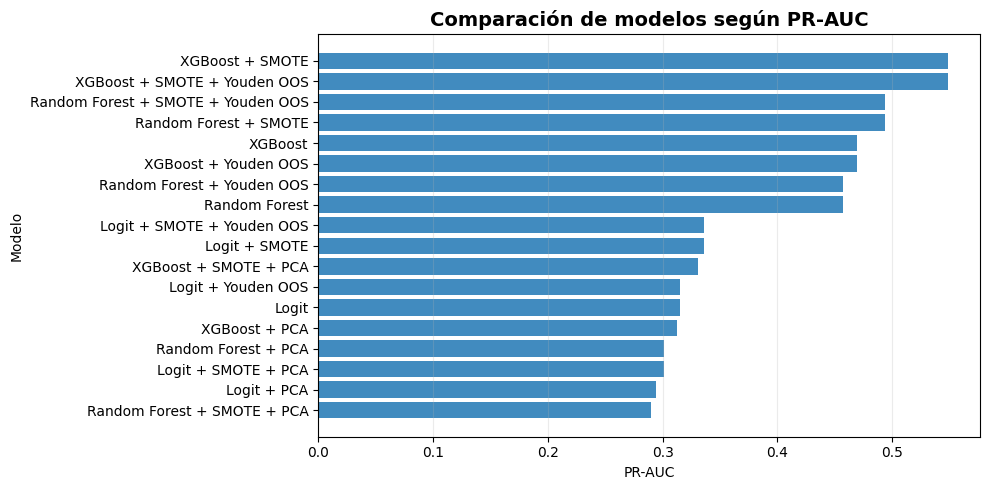

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))
orden_pr = comparacion_modelos.sort_values("PR-AUC")

ax.barh(orden_pr["Modelo"], orden_pr["PR-AUC"], alpha=0.85)
ax.set_title("Comparación de modelos según PR-AUC", fontsize=14, fontweight="bold")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("Modelo")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

**Comparación Recall y F2**

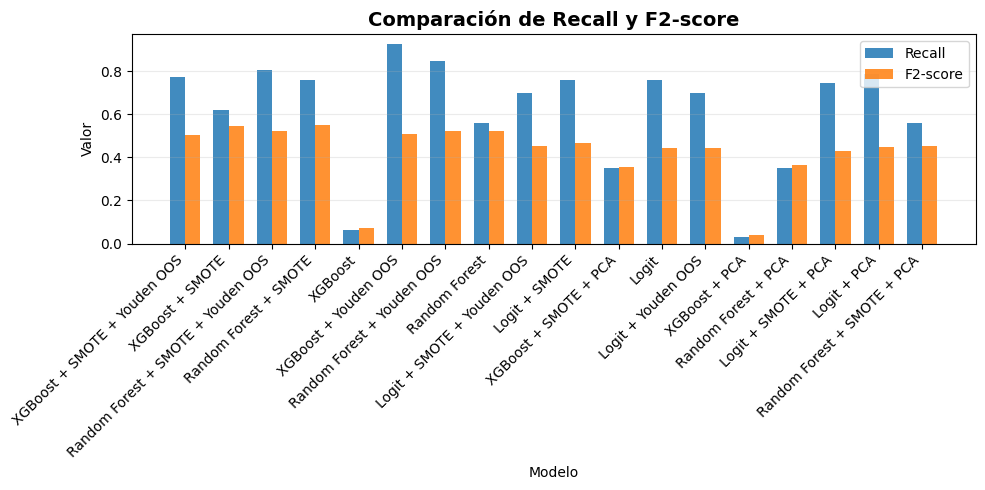

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(comparacion_modelos))
width = 0.35

ax.bar(x_pos - width/2, comparacion_modelos["Recall"], width, label="Recall", alpha=0.85)
ax.bar(x_pos + width/2, comparacion_modelos["F2-score"], width, label="F2-score", alpha=0.85)

ax.set_title("Comparación de Recall y F2-score", fontsize=14, fontweight="bold")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.set_xticks(x_pos)
ax.set_xticklabels(comparacion_modelos["Modelo"], rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## 18. Interpretabilidad con SHAP

La interpretabilidad es una condición necesaria para que un modelo de riesgo financiero sea defendible. SHAP permite explicar qué variables empujan una predicción hacia la quiebra o hacia la solvencia. En esta sección se aplica SHAP al mejor modelo de árbol entre Random Forest y XGBoost, considerando tanto las versiones base como las versiones con SMOTE.

In [65]:

tree_model_names = ["Random Forest", "Random Forest + SMOTE", "XGBoost", "XGBoost + SMOTE"]
metricas_arboles = comparacion_modelos[comparacion_modelos["Modelo"].isin(tree_model_names)].copy()
mejor_modelo_arbol = metricas_arboles.sort_values("PR-AUC", ascending=False).iloc[0]["Modelo"]

print("Mejor modelo de árbol para SHAP:", mejor_modelo_arbol)

if mejor_modelo_arbol == "Random Forest":
    modelo_shap = best_rf
    modelo_prediccion_shap = best_rf
elif mejor_modelo_arbol == "Random Forest + SMOTE":
    modelo_shap = modelo_rf_smote.named_steps["rf"]
    modelo_prediccion_shap = modelo_rf_smote
elif mejor_modelo_arbol == "XGBoost":
    modelo_shap = best_xgb
    modelo_prediccion_shap = best_xgb
elif mejor_modelo_arbol == "XGBoost + SMOTE":
    modelo_shap = modelo_xgb_smote.named_steps["xgb"]
    modelo_prediccion_shap = modelo_xgb_smote
else:
    raise ValueError("No se ha podido identificar el modelo para SHAP.")

Mejor modelo de árbol para SHAP: XGBoost + SMOTE


In [66]:
X_test_shap = X_test.copy()

explainer = shap.TreeExplainer(modelo_shap)
shap_values = explainer(X_test_shap, check_additivity=False)

shap_array = shap_values.values

if shap_array.ndim == 3:
    shap_array_clase_positiva = shap_array[:, :, 1]
else:
    shap_array_clase_positiva = shap_array

print("Dimensión de la matriz SHAP utilizada:")
print(shap_array_clase_positiva.shape)

Dimensión de la matriz SHAP utilizada:
(2046, 93)


In [67]:
shap_importance = pd.DataFrame({"Variable": X_test_shap.columns,"Importancia_SHAP_media_abs": np.abs(shap_array_clase_positiva).mean(axis=0)}).sort_values("Importancia_SHAP_media_abs", ascending=False)

shap_importance.head(20)

,Variable,Importancia_SHAP_media_abs
9,Continuous interest rate (after tax),1.213826
35,Total debt/Total net worth,1.192200
67,Retained Earnings to Total Assets,0.527850
52,Allocation rate per person,0.467286
33,Quick Ratio,0.405664
27,Continuous Net Profit Growth Rate,0.349459
39,Borrowing dependency,0.342370
13,Interest-bearing debt interest rate,0.306071
40,Contingent liabilities/Net worth,0.242115
8,Non-industry income and expenditure/revenue,0.236274


**Variables importantes para SHAP**

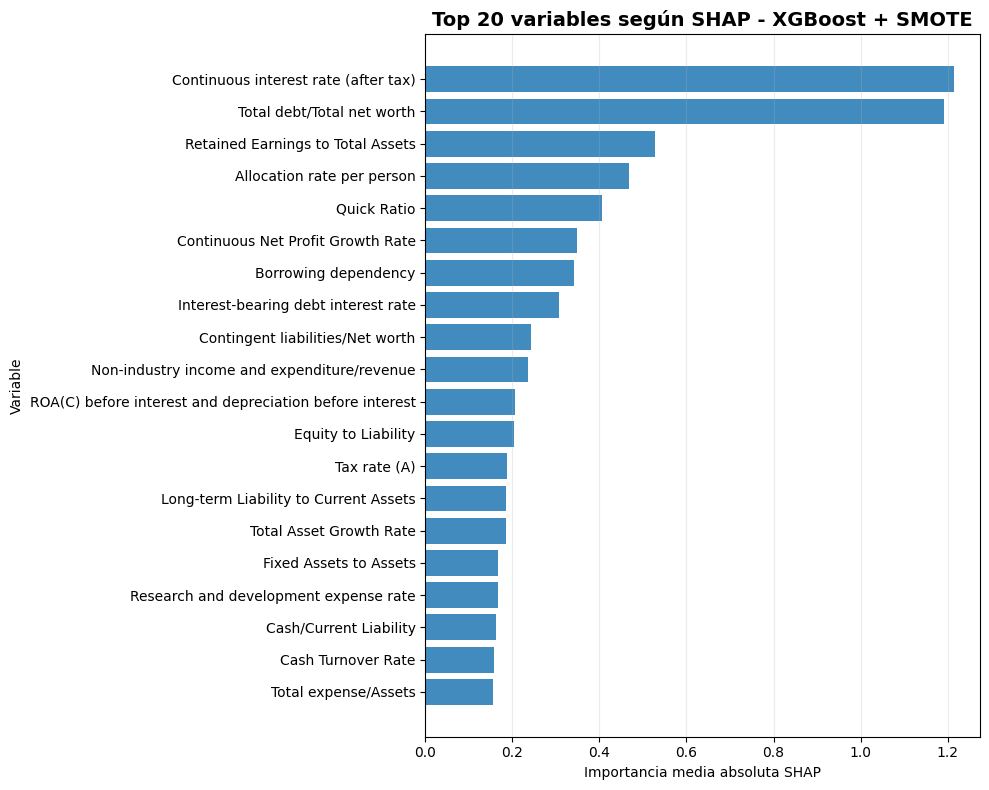

In [68]:
top_20_shap = shap_importance.head(20).sort_values("Importancia_SHAP_media_abs")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20_shap["Variable"], top_20_shap["Importancia_SHAP_media_abs"], alpha=0.85)
ax.set_title(f"Top 20 variables según SHAP - {mejor_modelo_arbol}", fontsize=14, fontweight="bold")
ax.set_xlabel("Importancia media absoluta SHAP")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

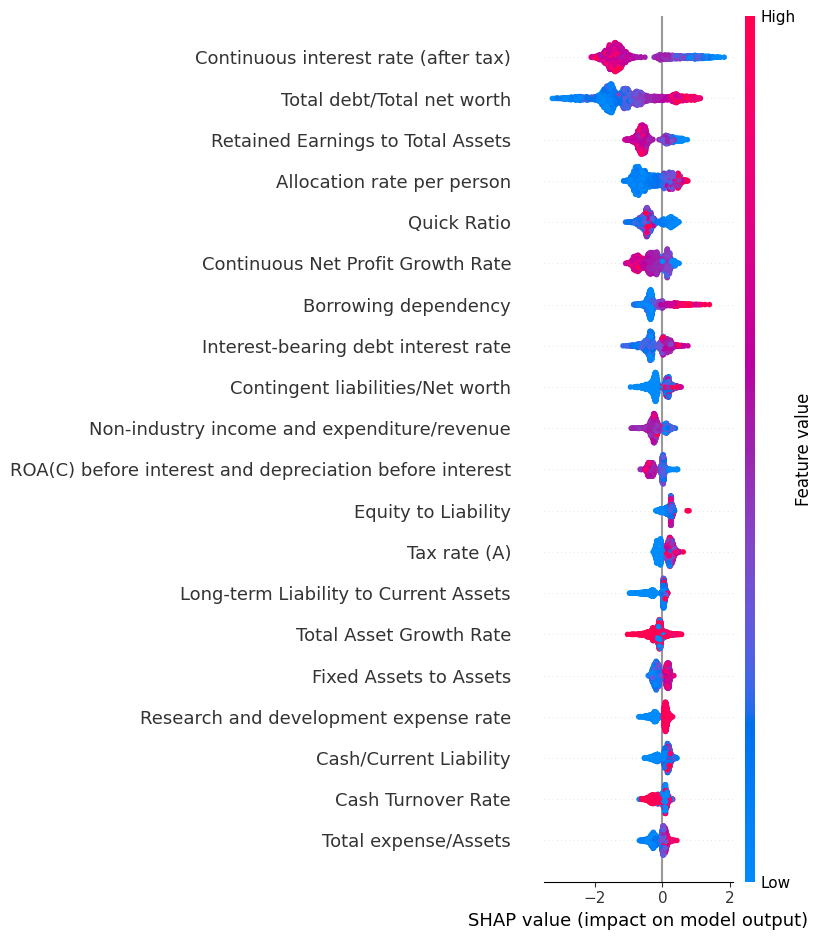

In [69]:
shap.summary_plot(shap_array_clase_positiva,X_test_shap,max_display=20,show=True)

El gráfico resumen de SHAP permite observar no solo qué variables son importantes, sino también la dirección de su efecto. Los puntos situados hacia la derecha empujan la predicción hacia mayor probabilidad de quiebra, mientras que los situados hacia la izquierda reducen dicha probabilidad. Esta lectura es especialmente útil en finanzas porque permite transformar un modelo de caja negra en una herramienta explicable de apoyo a la decisión.

**Waterfall plot**

Umbral utilizado para seleccionar el caso SHAP: 0.2798
Se selecciona una empresa quebrada correctamente detectada.
Índice de la empresa seleccionada: 1179
y_real           1.000000
y_pred           1.000000
proba_quiebra    0.994933
Name: 1179, dtype: float64


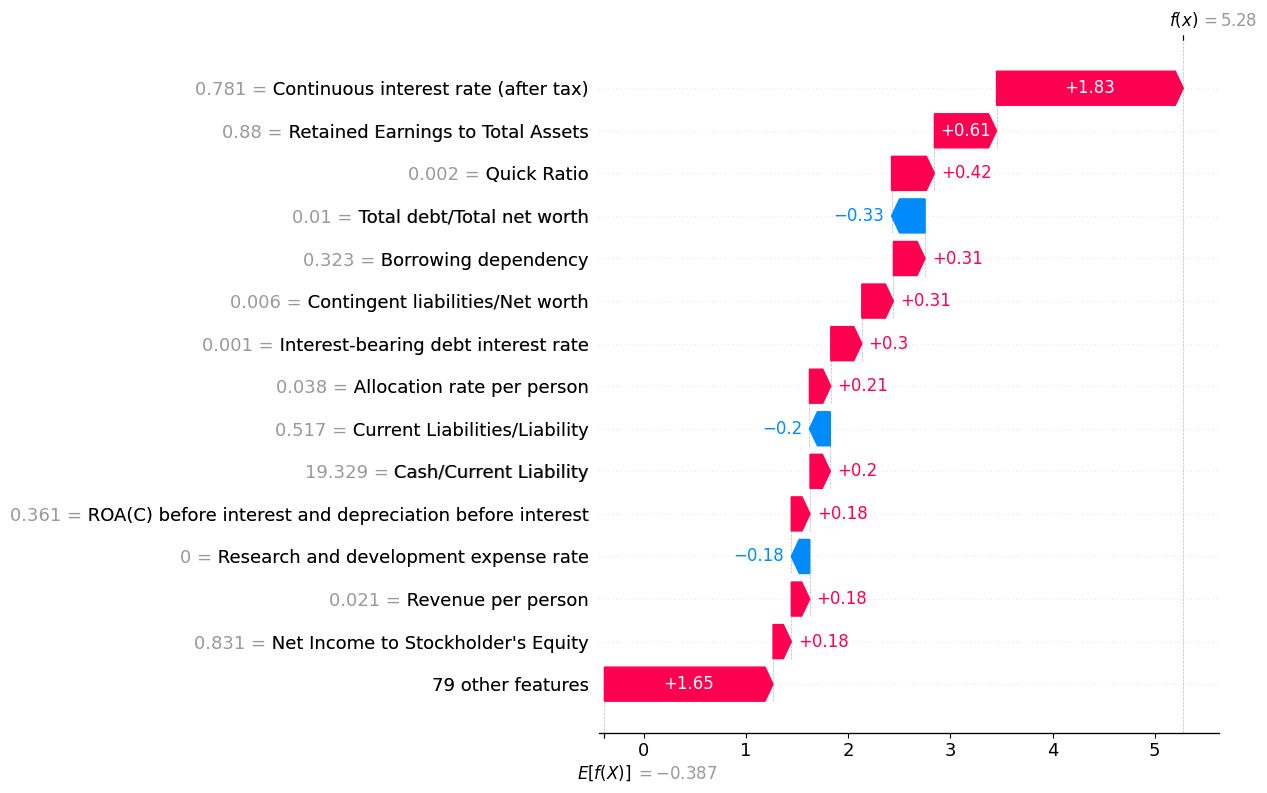

In [70]:
y_proba_shap = modelo_prediccion_shap.predict_proba(X_test)[:, 1]
umbral_shap = umbrales_youden.get(mejor_modelo_arbol, 0.5)
y_pred_shap = (y_proba_shap >= umbral_shap).astype(int)

print(f"Umbral utilizado para seleccionar el caso SHAP: {umbral_shap:.4f}")

resultados_test_shap = pd.DataFrame({"y_real": y_test.values,"y_pred": y_pred_shap,"proba_quiebra": y_proba_shap}, index=X_test.index)

quebradas_bien_detectadas = resultados_test_shap[(resultados_test_shap["y_real"] == 1) & (resultados_test_shap["y_pred"] == 1)]

if len(quebradas_bien_detectadas) > 0:
    idx_empresa = quebradas_bien_detectadas.sort_values("proba_quiebra", ascending=False).index[0]
    print("Se selecciona una empresa quebrada correctamente detectada.")
elif (resultados_test_shap["y_real"] == 1).sum() > 0:
    idx_empresa = resultados_test_shap[resultados_test_shap["y_real"] == 1].sort_values("proba_quiebra", ascending=False).index[0]
    print("No hay quebradas correctamente detectadas; se selecciona la quebrada con mayor probabilidad estimada.")
else:
    idx_empresa = resultados_test_shap.sort_values("proba_quiebra", ascending=False).index[0]
    print("No hay empresas quebradas en test; se selecciona la observación con mayor probabilidad estimada.")

pos_empresa = list(X_test.index).index(idx_empresa)

print("Índice de la empresa seleccionada:", idx_empresa)
print(resultados_test_shap.loc[idx_empresa])

if shap_array.ndim == 3:
    shap.plots.waterfall(shap_values[pos_empresa, :, 1], max_display=15)
else:
    shap.plots.waterfall(shap_values[pos_empresa], max_display=15)

El waterfall plot explica una predicción individual. Muestra el valor base del modelo y cómo cada variable financiera desplaza la predicción hacia mayor o menor riesgo.

## 19. Conclusiones

Dado que la quiebra empresarial es una clase minoritaria, el PR-AUC ofrece una visión más adecuada del desempeño del modelo sobre la clase positiva. Asimismo, recall y F2-score son métricas especialmente relevantes cuando se busca reducir falsos negativos, ya que clasificar como solvente a una empresa que finalmente quiebra puede ser peor que generar una alerta preventiva sobre una empresa sana.

El efecto de SMOTE puede mejorar la detección de empresas quebradas al reforzar la clase minoritaria, pero también puede reducir la precisión si genera más falsas alarmas. Por tanto, no debe asumirse que SMOTE siempre mejora el modelo, su utilidad depende del equilibrio entre PR-AUC, recall, F2-score y especificidad.

Los modelos de ensemble, especialmente Random Forest y XGBoost, se justifican por su capacidad para capturar relaciones no lineales entre ratios financieros. Sin embargo, su mayor complejidad exige una capa de interpretabilidad. SHAP permite identificar qué variables tienen más peso global y explicar predicciones individuales, conectando el rendimiento predictivo con la transparencia necesaria en aplicaciones financieras.

La incorporación de PCA permite comparar los modelos originales con una versión basada en componentes principales. Si las métricas mejoran o se mantienen, puede interpretarse que PCA conserva una parte importante de la información del dataset con menor dimensionalidad. Si empeoran, especialmente en PR-AUC o recall, puede deberse a que la transformación lineal pierde información útil para identificar empresas quebradas. Por este motivo, PCA se analiza como comparación metodológica, no como sustitución automática de los modelos originales.

## 20. Tablas comparativas finales

Se presentan tres tablas separadas para no mezclar criterios de umbral en una misma ordenación:

- **Tabla A** — Selección final con umbral Youden *cross-validated out-of-sample* (criterio definitivo).
- **Tabla B** — Contraste del umbral *in-sample* frente al *cross-validated out-of-sample* por modelo.
- **Tabla C** — Todos los modelos con umbral *in-sample*, incluyendo las versiones con PCA.

In [71]:
_df_oof = pd.DataFrame(resultados_modelos_oof)

tabla_A = _df_oof[["Modelo", "Umbral", "Accuracy", "Precision", "Recall","F2-score", "Specificity", "ROC-AUC", "PR-AUC"]].sort_values("PR-AUC", ascending=False).reset_index(drop=True)

print("TABLA A — Selección final (umbral Youden cross-validated out-of-sample):")
tabla_A.round(4)

TABLA A — Selección final (umbral Youden cross-validated out-of-sample):


,Modelo,Umbral,Accuracy,Precision,Recall,F2-score,Specificity,ROC-AUC,PR-AUC
0,XGBoost + SMOTE + Youden OOS,0.0452,0.8983,0.2090,0.7727,0.5020,0.9025,0.9471,0.5491
1,Random Forest + SMOTE + Youden OOS,0.2829,0.8998,0.2163,0.8030,0.5206,0.9030,0.9514,0.4941
2,XGBoost + Youden OOS,0.0124,0.8622,0.1805,0.9242,0.5066,0.8601,0.9548,0.4691
3,Random Forest + Youden OOS,0.1569,0.8895,0.2059,0.8485,0.5224,0.8909,0.9526,0.4575
4,Logit + SMOTE + Youden OOS,0.4323,0.8944,0.1901,0.6970,0.4545,0.9010,0.8990,0.3357
5,Logit + Youden OOS,0.5155,0.8881,0.1804,0.6970,0.4432,0.8944,0.9031,0.3150


In [72]:
_df_all = pd.DataFrame(resultados_modelos)
_df_in = _df_all[~_df_all["Modelo"].str.contains("Youden OOS")]
_df_oof_b = pd.DataFrame(resultados_modelos_oof)

_pares = [("Logit", "Logit + Youden OOS"),("Logit + SMOTE", "Logit + SMOTE + Youden OOS"),("Random Forest", "Random Forest + Youden OOS"), ("Random Forest + SMOTE", "Random Forest + SMOTE + Youden OOS"), ("XGBoost", "XGBoost + Youden OOS"), ("XGBoost + SMOTE", "XGBoost + SMOTE + Youden OOS"),]

_filas = []
for _nin, _noof in _pares:
    _fi = _df_in[_df_in["Modelo"] == _nin]
    _fo = _df_oof_b[_df_oof_b["Modelo"] == _noof]
    if not _fi.empty and not _fo.empty:
        _fi, _fo = _fi.iloc[0], _fo.iloc[0]
        _filas.append({"Modelo": _nin,"Umbral (in-sample)": _fi["Umbral"],"Umbral (OOS)": _fo["Umbral"],"Recall (in-sample)": _fi["Recall"],"Recall (OOS)": _fo["Recall"],"F2 (in-sample)": _fi["F2-score"],"F2 (OOS)": _fo["F2-score"],})

tabla_B = pd.DataFrame(_filas)
print("TABLA B — Contraste umbral in-sample vs cross-validated out-of-sample:")
tabla_B.round(4)

TABLA B — Contraste umbral in-sample vs cross-validated out-of-sample:


,Modelo,Umbral (in-sample),Umbral (OOS),Recall (in-sample),Recall (OOS),F2 (in-sample),F2 (OOS)
0,Logit,0.4486,0.5155,0.7576,0.6970,0.4433,0.4432
1,Logit + SMOTE,0.3741,0.4323,0.7576,0.6970,0.4647,0.4545
2,Random Forest,0.5007,0.1569,0.5606,0.8485,0.5226,0.5224
3,Random Forest + SMOTE,0.3805,0.2829,0.7576,0.8030,0.5507,0.5206
4,XGBoost,0.9734,0.0124,0.0606,0.9242,0.0738,0.5066
5,XGBoost + SMOTE,0.2798,0.0452,0.6212,0.7727,0.5467,0.5020


In [73]:
_df_c = pd.DataFrame(resultados_modelos)
_df_c = _df_c[~_df_c["Modelo"].str.contains("Youden OOS")].copy()

for _col, _def in [("PCA", "No"), ("N componentes PCA", "-")]:
    if _col not in _df_c.columns:
        _df_c[_col] = _def
    _df_c[_col] = _df_c[_col].fillna(_def)

tabla_C = _df_c[["Modelo", "PCA", "N componentes PCA", "Umbral","Accuracy", "Precision", "Recall", "Specificity","F1-score", "F2-score", "ROC-AUC", "PR-AUC"]].sort_values("PR-AUC", ascending=False).reset_index(drop=True)

print("TABLA C — Todos los modelos (umbral in-sample, incluye PCA):")
tabla_C.round(4)

TABLA C — Todos los modelos (umbral in-sample, incluye PCA):


,Modelo,PCA,N componentes PCA,Umbral,Accuracy,Precision,Recall,Specificity,F1-score,F2-score,ROC-AUC,PR-AUC
0,XGBoost + SMOTE,No,-,0.2798,0.9536,0.3694,0.6212,0.9646,0.4633,0.5467,0.9471,0.5491
1,Random Forest + SMOTE,No,-,0.3805,0.9238,0.2632,0.7576,0.9293,0.3906,0.5507,0.9514,0.4941
2,XGBoost,No,-,0.9734,0.9682,0.5714,0.0606,0.9985,0.1096,0.0738,0.9548,0.4691
3,Random Forest,No,-,0.5007,0.9599,0.4111,0.5606,0.9732,0.4744,0.5226,0.9526,0.4575
4,Logit + SMOTE,No,-,0.3741,0.8827,0.1825,0.7576,0.8869,0.2941,0.4647,0.8990,0.3357
5,XGBoost + SMOTE + PCA,Sí,39,0.7513,0.9614,0.3898,0.3485,0.9818,0.3680,0.3560,0.9145,0.3305
6,Logit,No,-,0.4486,0.8700,0.1667,0.7576,0.8737,0.2732,0.4433,0.9031,0.3150
7,XGBoost + PCA,Sí,39,0.9645,0.9682,0.6667,0.0303,0.9995,0.0580,0.0375,0.9181,0.3124
8,Random Forest + PCA,Sí,39,0.5040,0.9648,0.4423,0.3485,0.9854,0.3898,0.3639,0.9180,0.3014
9,Logit + SMOTE + PCA,Sí,39,0.4061,0.8671,0.1612,0.7424,0.8712,0.2649,0.4313,0.8962,0.3011
